In [1]:
import numpy as np 
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/nafiisaa/cert-dataset/logon.csv
/kaggle/input/datasets/nafiisaa/cert-dataset/file.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Tuesday-WorkingHours.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Monday-WorkingHours.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Friday-WorkingHours-Morning.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Wednesday-workingHours.pcap_ISCX.csv


In [2]:
# =========================
# STEP 1: DATA ACQUISITION
# =========================

import os
import glob
import gc
import json
import pandas as pd

# -------------------------
# Output setup
# -------------------------
STEP1_OUT_DIR = "/kaggle/working/step1_outputs"
os.makedirs(STEP1_OUT_DIR, exist_ok=True)

MANIFEST_PATH = os.path.join(STEP1_OUT_DIR, "data_manifest.json")
FILE_INDEX_PATH = os.path.join(STEP1_OUT_DIR, "input_file_index.csv")

# -------------------------
# Helpers
# -------------------------
def clean_colname(c):
    c = str(c).strip().lower()
    for ch in [" ", "-", "/", ".", "(", ")", ":"]:
        c = c.replace(ch, "_")
    while "__" in c:
        c = c.replace("__", "_")
    return c.strip("_")

def free_memory(*objs):
    for obj in objs:
        try:
            del obj
        except:
            pass
    gc.collect()

def safe_read_head(path, nrows=3):
    """
    Read a tiny sample only.
    Uses dtype=str to avoid large type inference memory overhead.
    """
    return pd.read_csv(path, nrows=nrows, dtype=str, low_memory=True)

def inspect_csv(path, name="", nrows=3):
    print("=" * 110)
    print("NAME  :", name if name else os.path.basename(path))
    print("PATH  :", path)
    print("EXISTS:", os.path.exists(path))

    if not os.path.exists(path):
        print("Missing file.")
        return {
            "path": path,
            "exists": False,
            "rows_previewed": 0,
            "num_columns": 0,
            "columns_original": [],
            "columns_cleaned": []
        }

    try:
        df = safe_read_head(path, nrows=nrows)
        original_cols = df.columns.tolist()
        cleaned_cols = [clean_colname(c) for c in original_cols]

        print("ROWS PREVIEWED   :", len(df))
        print("NUMBER OF COLUMNS:", len(original_cols))
        print("ORIGINAL COLUMNS :", original_cols)
        print("CLEANED COLUMNS  :", cleaned_cols)

        display(df.head(min(2, len(df))))

        meta = {
            "path": path,
            "exists": True,
            "rows_previewed": int(len(df)),
            "num_columns": int(len(original_cols)),
            "columns_original": original_cols,
            "columns_cleaned": cleaned_cols
        }

        free_memory(df)
        return meta

    except Exception as e:
        print("ERROR READING FILE:", repr(e))
        return {
            "path": path,
            "exists": True,
            "rows_previewed": 0,
            "num_columns": 0,
            "columns_original": [],
            "columns_cleaned": [],
            "error": repr(e)
        }

def find_first_existing_file(candidates):
    for p in candidates:
        if os.path.exists(p):
            return p
    return None

def find_all_csvs_under(base_dir):
    if not os.path.exists(base_dir):
        return []
    return sorted(glob.glob(os.path.join(base_dir, "**", "*.csv"), recursive=True))

def find_dataset_root_by_keywords(required_files=None, required_keywords=None):
    """
    Search /kaggle/input recursively and return the best matching folder.
    """
    required_files = required_files or []
    required_keywords = [k.lower() for k in (required_keywords or [])]

    candidate_dirs = set()

    for root, dirs, files in os.walk("/kaggle/input"):
        files_lower = {f.lower() for f in files}
        root_lower = root.lower()

        file_match = all(f.lower() in files_lower for f in required_files) if required_files else True
        kw_match = all(k in root_lower for k in required_keywords) if required_keywords else True

        if file_match and kw_match:
            candidate_dirs.add(root)

    if not candidate_dirs:
        return None

    # Prefer the shortest matching path
    return sorted(candidate_dirs, key=lambda x: (len(x), x))[0]

# -------------------------
# 1A. Build input file index
# -------------------------
all_input_files = []
for root, _, files in os.walk("/kaggle/input"):
    for f in files:
        full_path = os.path.join(root, f)
        try:
            size_mb = os.path.getsize(full_path) / (1024 * 1024)
        except:
            size_mb = None
        all_input_files.append({
            "path": full_path,
            "filename": f,
            "extension": os.path.splitext(f)[1].lower(),
            "size_mb": round(size_mb, 4) if size_mb is not None else None
        })

file_index_df = pd.DataFrame(all_input_files).sort_values(["path"]).reset_index(drop=True)
file_index_df.to_csv(FILE_INDEX_PATH, index=False)

print("Saved input file index:", FILE_INDEX_PATH)
print("Total files found under /kaggle/input:", len(file_index_df))

# -------------------------
# 1B. Resolve CERT dataset robustly
# -------------------------
cert_root = find_dataset_root_by_keywords(
    required_files=["logon.csv", "file.csv"],
    required_keywords=["cert"]
)

# fallback guesses if keyword-based match fails
if cert_root is None:
    cert_root = find_first_existing_file([
        "/kaggle/input/cert-dataset",
        "/kaggle/input/datasets/nafiisaa/cert-dataset"
    ])
    if cert_root is not None and os.path.isfile(cert_root):
        cert_root = os.path.dirname(cert_root)

CERT_LOGON_PATH = None
CERT_FILE_PATH = None

if cert_root is not None:
    CERT_LOGON_PATH = find_first_existing_file([
        os.path.join(cert_root, "logon.csv"),
        os.path.join(cert_root, "LOGON.csv")
    ])
    CERT_FILE_PATH = find_first_existing_file([
        os.path.join(cert_root, "file.csv"),
        os.path.join(cert_root, "FILE.csv")
    ])

# -------------------------
# 1C. Resolve CIC dataset robustly
# -------------------------
cic_root = find_dataset_root_by_keywords(
    required_keywords=["network", "intrusion"]
)

# fallback guesses
fallback_cic_dirs = [
    "/kaggle/input/network-intrusion-dataset",
    "/kaggle/input/cic-ids-2017",
    "/kaggle/input/datasets/chethuhn/network-intrusion-dataset"
]

if cic_root is None:
    for d in fallback_cic_dirs:
        if os.path.exists(d):
            cic_root = d
            break

CIC_PATHS = find_all_csvs_under(cic_root) if cic_root is not None else []

# Keep likely CIC traffic CSVs only
if CIC_PATHS:
    filtered = []
    for p in CIC_PATHS:
        name = os.path.basename(p).lower()
        if any(x in name for x in [
            "workinghours", "portscan", "ddos", "dos", "bot", "webattack",
            "infilteration", "ftp", "ssh", "heartbleed", "pcap"
        ]):
            filtered.append(p)
    if len(filtered) > 0:
        CIC_PATHS = sorted(filtered)

# -------------------------
# 1D. Show resolved paths
# -------------------------
print("\n" + "=" * 110)
print("RESOLVED DATASET PATHS")
print("=" * 110)
print("CERT ROOT       :", cert_root)
print("CERT_LOGON_PATH :", CERT_LOGON_PATH)
print("CERT_FILE_PATH  :", CERT_FILE_PATH)
print("CIC ROOT        :", cic_root)
print("CIC FILE COUNT  :", len(CIC_PATHS))

for p in CIC_PATHS:
    print(" -", os.path.basename(p))

# -------------------------
# 1E. Inspect files safely
# -------------------------
manifest = {
    "cert_root": cert_root,
    "cic_root": cic_root,
    "cert_logon_path": CERT_LOGON_PATH,
    "cert_file_path": CERT_FILE_PATH,
    "cic_paths": CIC_PATHS,
    "cert_logon_meta": None,
    "cert_file_meta": None,
    "cic_meta": []
}

if CERT_LOGON_PATH:
    manifest["cert_logon_meta"] = inspect_csv(CERT_LOGON_PATH, name="CERT logon.csv", nrows=3)
else:
    print("\nCERT logon.csv not found.")

if CERT_FILE_PATH:
    manifest["cert_file_meta"] = inspect_csv(CERT_FILE_PATH, name="CERT file.csv", nrows=3)
else:
    print("\nCERT file.csv not found.")

if CIC_PATHS:
    print("\nInspecting CIC files safely...")
    for p in CIC_PATHS:
        meta = inspect_csv(p, name=os.path.basename(p), nrows=2)
        manifest["cic_meta"].append(meta)
else:
    print("\nNo CIC CSV files found.")

# -------------------------
# 1F. Hard validation for downstream steps
# -------------------------
issues = []

if CERT_LOGON_PATH is None:
    issues.append("CERT logon.csv not found")
if CERT_FILE_PATH is None:
    issues.append("CERT file.csv not found")
if len(CIC_PATHS) == 0:
    issues.append("No CIC CSV files found")

manifest["issues"] = issues
manifest["status"] = "ok" if len(issues) == 0 else "check_paths"

with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("\nSaved manifest:", MANIFEST_PATH)

if issues:
    print("\n STEP 1 completed with path issues:")
    for x in issues:
        print(" -", x)
else:
    print("\n STEP 1 COMPLETE: datasets resolved correctly and previewed safely.")

Saved input file index: /kaggle/working/step1_outputs/input_file_index.csv
Total files found under /kaggle/input: 10

RESOLVED DATASET PATHS
CERT ROOT       : /kaggle/input/datasets/nafiisaa/cert-dataset
CERT_LOGON_PATH : /kaggle/input/datasets/nafiisaa/cert-dataset/logon.csv
CERT_FILE_PATH  : /kaggle/input/datasets/nafiisaa/cert-dataset/file.csv
CIC ROOT        : /kaggle/input/datasets/chethuhn/network-intrusion-dataset
CIC FILE COUNT  : 8
 - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
 - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 - Friday-WorkingHours-Morning.pcap_ISCX.csv
 - Monday-WorkingHours.pcap_ISCX.csv
 - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
 - Tuesday-WorkingHours.pcap_ISCX.csv
 - Wednesday-workingHours.pcap_ISCX.csv
NAME  : CERT logon.csv
PATH  : /kaggle/input/datasets/nafiisaa/cert-dataset/logon.csv
EXISTS: True
ROWS PREVIEWED   : 3
NUMBER OF COLUMNS: 5
ORIGINAL COLUMNS : ['id',

,id,date,user,pc,activity
0,{F3X8-Y2GT43DR-4906OHBL},01/02/2010 02:19:18,DNS1758,PC-0414,Logon
1,{B4Q0-D0GM24KN-3704MAII},01/02/2010 02:31:12,DNS1758,PC-0414,Logoff


NAME  : CERT file.csv
PATH  : /kaggle/input/datasets/nafiisaa/cert-dataset/file.csv
EXISTS: True
ROWS PREVIEWED   : 3
NUMBER OF COLUMNS: 9
ORIGINAL COLUMNS : ['id', 'date', 'user', 'pc', 'filename', 'activity', 'to_removable_media', 'from_removable_media', 'content']
CLEANED COLUMNS  : ['id', 'date', 'user', 'pc', 'filename', 'activity', 'to_removable_media', 'from_removable_media', 'content']


,id,date,user,pc,filename,activity,to_removable_media,from_removable_media,content
0,{F3E2-X3MV05YQ-3516SZDT},01/02/2010 07:19:41,SDH2394,PC-5849,R:\60WBQE7S.doc,File Open,False,True,"D0-CF-11-E0-A1-B1-1A-E1 Ernesztin's brother, L..."
1,{I6N1-Z7VL92UY-8715ESKQ},01/02/2010 07:21:30,SDH2394,PC-5849,R:\0VGILDW8.pdf,File Write,True,False,25-50-44-46-2D ---- Bengali As do many other T...



Inspecting CIC files safely...
NAME  : Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
PATH  : /kaggle/input/datasets/chethuhn/network-intrusion-dataset/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
EXISTS: True
ROWS PREVIEWED   : 2
NUMBER OF COLUMNS: 79
ORIGINAL COLUMNS : [' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',

...

NAME  : Tuesday-WorkingHours.pcap_ISCX.csv
PATH  : /kaggle/input/datasets/chethuhn/network-intrusion-dataset/Tuesday-WorkingHours.pcap_ISCX.csv
EXISTS: True
ROWS PREVIEWED   : 2
NUMBER OF COLUMNS: 79
ORIGINAL COLUMNS : [' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' 

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,88,640,7,4,440,358,220,0,62.85714286,107.349008,...,20,0,0,0,0,0,0,0,0,BENIGN
1,88,900,9,4,600,2944,300,0,66.66666667,132.2875656,...,20,0,0,0,0,0,0,0,0,BENIGN


NAME  : Wednesday-workingHours.pcap_ISCX.csv
PATH  : /kaggle/input/datasets/chethuhn/network-intrusion-dataset/Wednesday-workingHours.pcap_ISCX.csv
EXISTS: True
ROWS PREVIEWED   : 2
NUMBER OF COLUMNS: 79
ORIGINAL COLUMNS : [' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s'

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6,0,...,20,0,0,0,0,0,0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.63636364,31.4492376,...,32,0,0,0,0,0,0,0,0,BENIGN



Saved manifest: /kaggle/working/step1_outputs/data_manifest.json

 STEP 1 COMPLETE: datasets resolved correctly and previewed safely.


In [3]:
# =========================
# STEP 2: DATA CLEANING & NORMALIZATION
# =========================

import os
import gc
import json
import re
import numpy as np
import pandas as pd

# -------------------------
# Paths
# -------------------------
STEP1_OUT_DIR = "/kaggle/working/step1_outputs"
STEP2_OUT_DIR = "/kaggle/working/step2_outputs"
os.makedirs(STEP2_OUT_DIR, exist_ok=True)

MANIFEST_PATH = os.path.join(STEP1_OUT_DIR, "data_manifest.json")
CERT_CLEAN_LOGON_PATH = os.path.join(STEP2_OUT_DIR, "cert_logon_clean.parquet")
CERT_CLEAN_FILE_PATH  = os.path.join(STEP2_OUT_DIR, "cert_file_clean.parquet")
CIC_CLEAN_DIR = os.path.join(STEP2_OUT_DIR, "cic_clean_parts")
os.makedirs(CIC_CLEAN_DIR, exist_ok=True)

STEP2_SUMMARY_PATH = os.path.join(STEP2_OUT_DIR, "step2_summary.json")

# -------------------------
# Load manifest from Step 1
# -------------------------
with open(MANIFEST_PATH, "r", encoding="utf-8") as f:
    manifest = json.load(f)

CERT_LOGON_PATH = manifest.get("cert_logon_path")
CERT_FILE_PATH  = manifest.get("cert_file_path")
CIC_PATHS       = manifest.get("cic_paths", [])

print("Loaded Step 1 manifest")
print("CERT_LOGON_PATH:", CERT_LOGON_PATH)
print("CERT_FILE_PATH :", CERT_FILE_PATH)
print("CIC file count :", len(CIC_PATHS))

# -------------------------
# Utilities
# -------------------------
def free_memory(*objs):
    for obj in objs:
        try:
            del obj
        except:
            pass
    gc.collect()

def clean_colname(c):
    c = str(c).strip().lower()
    c = c.replace("(", "_").replace(")", "_")
    c = c.replace("/", "_").replace("\\", "_")
    c = c.replace("-", "_").replace(".", "_")
    c = c.replace(" ", "_").replace(":", "_")
    c = re.sub(r"_+", "_", c).strip("_")
    return c

def standardize_columns(df):
    df = df.copy()
    df.columns = [clean_colname(c) for c in df.columns]
    return df

def normalize_text_value(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    x = re.sub(r"\s+", "_", x)
    return x

def coerce_numeric_columns(df, exclude=None):
    exclude = set(exclude or [])
    for c in df.columns:
        if c in exclude:
            continue
        if df[c].dtype == object:
            converted = pd.to_numeric(df[c], errors="coerce")
            non_null_ratio = converted.notna().mean()
            # only adopt numeric conversion if it seems meaningful
            if non_null_ratio >= 0.80:
                df[c] = converted
    return df

def safe_datetime_parse(series):
    s1 = pd.to_datetime(series, errors="coerce", infer_datetime_format=True)
    return s1

def choose_existing(cols, candidates):
    for cand in candidates:
        if cand in cols:
            return cand
    return None

# -------------------------
# CERT cleaning
# -------------------------
def clean_cert_file(path, out_path, dataset_name):
    if path is None or not os.path.exists(path):
        print(f"Skipping {dataset_name}: file not found")
        return None

    print(f"\nCleaning CERT dataset: {dataset_name}")
    df = pd.read_csv(path, low_memory=True)
    df = standardize_columns(df)

    original_rows, original_cols = df.shape

    # Normalize text columns lightly
    for c in df.columns:
        if df[c].dtype == object:
            # avoid converting very high-cardinality raw fields blindly if huge
            sample_non_null = df[c].dropna().astype(str).head(200)
            avg_len = sample_non_null.str.len().mean() if len(sample_non_null) else 0
            if avg_len < 100:
                df[c] = df[c].map(normalize_text_value)

    # Common CERT aliases
    user_col = choose_existing(df.columns, ["user", "user_id", "employee", "employee_name"])
    pc_col   = choose_existing(df.columns, ["pc", "device", "host", "computer"])
    act_col  = choose_existing(df.columns, ["activity", "action", "op", "event"])
    date_col = choose_existing(df.columns, ["date", "timestamp", "time", "datetime"])

    if date_col is not None:
        df["timestamp"] = safe_datetime_parse(df[date_col])

    # Add source marker
    df["source_dataset"] = "cert"
    df["source_table"] = dataset_name

    # Create unified fields for later steps
    if user_col is not None:
        df["entity_id"] = df[user_col].astype(str)
    else:
        df["entity_id"] = "unknown_user"

    if pc_col is not None:
        df["asset_id"] = df[pc_col].astype(str)
    else:
        df["asset_id"] = "unknown_asset"

    if act_col is not None:
        df["raw_action"] = df[act_col].astype(str)
    else:
        df["raw_action"] = dataset_name

    # Remove exact duplicates
    before_dupes = len(df)
    df = df.drop_duplicates()
    after_dupes = len(df)

    # Save
    df.to_parquet(out_path, index=False)

    summary = {
        "dataset_name": dataset_name,
        "path": path,
        "output_path": out_path,
        "rows_before": int(original_rows),
        "cols_before": int(original_cols),
        "rows_after": int(len(df)),
        "cols_after": int(df.shape[1]),
        "duplicates_removed": int(before_dupes - after_dupes),
        "timestamp_non_null": int(df["timestamp"].notna().sum()) if "timestamp" in df.columns else 0,
        "entity_id_non_null": int(df["entity_id"].notna().sum()),
        "asset_id_non_null": int(df["asset_id"].notna().sum())
    }

    print(summary)
    free_memory(df)
    return summary

# -------------------------
# CIC cleaning
# -------------------------
def map_cic_columns(df):
    """
    Standardize CIC columns to a stable schema without using label-derived features
    for behavior construction.
    """
    cols = set(df.columns)

    mapped = {}

    # common identifiers
    mapped["src_ip_col"] = choose_existing(cols, ["source_ip", "src_ip"])
    mapped["dst_ip_col"] = choose_existing(cols, ["destination_ip", "dst_ip"])
    mapped["src_port_col"] = choose_existing(cols, ["source_port", "src_port"])
    mapped["dst_port_col"] = choose_existing(cols, ["destination_port", "dst_port"])
    mapped["protocol_col"] = choose_existing(cols, ["protocol"])

    # timestamps are inconsistent across CIC files; do NOT invent fake timestamps here
    mapped["timestamp_col"] = choose_existing(cols, ["timestamp", "flow_start_time", "date", "datetime"])

    # label
    mapped["label_col"] = choose_existing(cols, ["label"])

    # core traffic metrics
    mapped["flow_duration_col"] = choose_existing(cols, ["flow_duration"])
    mapped["tot_fwd_pkts_col"] = choose_existing(cols, ["total_fwd_packets", "tot_fwd_pkts"])
    mapped["tot_bwd_pkts_col"] = choose_existing(cols, ["total_backward_packets", "tot_bwd_pkts"])
    mapped["totlen_fwd_col"] = choose_existing(cols, ["total_length_of_fwd_packets", "totlen_fwd_pkts"])
    mapped["totlen_bwd_col"] = choose_existing(cols, ["total_length_of_bwd_packets", "totlen_bwd_pkts"])
    mapped["flow_byts_s_col"] = choose_existing(cols, ["flow_bytes_s"])
    mapped["flow_pkts_s_col"] = choose_existing(cols, ["flow_packets_s"])
    mapped["syn_flag_col"] = choose_existing(cols, ["syn_flag_count"])
    mapped["rst_flag_col"] = choose_existing(cols, ["rst_flag_count"])
    mapped["psh_flag_col"] = choose_existing(cols, ["psh_flag_count"])
    mapped["ack_flag_col"] = choose_existing(cols, ["ack_flag_count"])

    return mapped

def clean_cic_file(path, out_dir):
    print("\nCleaning CIC file:", os.path.basename(path))

    # Read full single file only; do not concatenate all CIC files in memory
    df = pd.read_csv(path, low_memory=True)
    df = standardize_columns(df)

    original_shape = df.shape
    mapping = map_cic_columns(df)

    # Normalize label safely
    label_col = mapping["label_col"]
    if label_col is not None:
        df["label"] = df[label_col].astype(str).map(normalize_text_value)
    else:
        df["label"] = "unknown"

    # Remove rows that are completely empty
    df = df.dropna(how="all")

    # Coerce numerics carefully
    protected_text_cols = [c for c in [
        mapping["src_ip_col"], mapping["dst_ip_col"], mapping["timestamp_col"], "label"
    ] if c is not None]

    df = coerce_numeric_columns(df, exclude=protected_text_cols)

    # Build standardized identifier columns
    if mapping["src_ip_col"] is not None:
        df["src_ip"] = df[mapping["src_ip_col"]].astype(str)
    else:
        df["src_ip"] = "unknown_src_ip"

    if mapping["dst_ip_col"] is not None:
        df["dst_ip"] = df[mapping["dst_ip_col"]].astype(str)
    else:
        df["dst_ip"] = "unknown_dst_ip"

    if mapping["src_port_col"] is not None:
        df["src_port"] = pd.to_numeric(df[mapping["src_port_col"]], errors="coerce")
    else:
        df["src_port"] = np.nan

    if mapping["dst_port_col"] is not None:
        df["dst_port"] = pd.to_numeric(df[mapping["dst_port_col"]], errors="coerce")
    else:
        df["dst_port"] = np.nan

    if mapping["protocol_col"] is not None:
        df["protocol_std"] = df[mapping["protocol_col"]]
    else:
        df["protocol_std"] = np.nan

    # Parse true timestamp only if present; do NOT synthesize time here
    ts_col = mapping["timestamp_col"]
    if ts_col is not None:
        df["timestamp"] = safe_datetime_parse(df[ts_col])
    else:
        df["timestamp"] = pd.NaT

    # Core numeric features for later modeling
    numeric_map = {
        "flow_duration": mapping["flow_duration_col"],
        "total_fwd_packets": mapping["tot_fwd_pkts_col"],
        "total_bwd_packets": mapping["tot_bwd_pkts_col"],
        "total_length_fwd_packets": mapping["totlen_fwd_col"],
        "total_length_bwd_packets": mapping["totlen_bwd_col"],
        "flow_bytes_per_sec": mapping["flow_byts_s_col"],
        "flow_packets_per_sec": mapping["flow_pkts_s_col"],
        "syn_flag_count": mapping["syn_flag_col"],
        "rst_flag_count": mapping["rst_flag_col"],
        "psh_flag_count": mapping["psh_flag_col"],
        "ack_flag_count": mapping["ack_flag_col"],
    }

    for std_col, raw_col in numeric_map.items():
        if raw_col is not None:
            df[std_col] = pd.to_numeric(df[raw_col], errors="coerce")
        else:
            df[std_col] = np.nan

    # Minimal cleanup
    before_dupes = len(df)
    df = df.drop_duplicates()
    after_dupes = len(df)

    # Keep only the columns needed for downstream work
    keep_cols = [
        "src_ip", "dst_ip", "src_port", "dst_port", "protocol_std", "timestamp", "label",
        "flow_duration", "total_fwd_packets", "total_bwd_packets",
        "total_length_fwd_packets", "total_length_bwd_packets",
        "flow_bytes_per_sec", "flow_packets_per_sec",
        "syn_flag_count", "rst_flag_count", "psh_flag_count", "ack_flag_count"
    ]

    slim = df[keep_cols].copy()
    slim["source_dataset"] = "cic_ids2017"
    slim["source_file"] = os.path.basename(path)

    # Important: remove impossible garbage labels formatting
    slim["label"] = slim["label"].fillna("unknown").astype(str).str.strip().str.lower()

    out_name = os.path.splitext(os.path.basename(path))[0] + "_clean.parquet"
    out_path = os.path.join(out_dir, out_name)
    slim.to_parquet(out_path, index=False)

    summary = {
        "input_path": path,
        "output_path": out_path,
        "rows_before": int(original_shape[0]),
        "cols_before": int(original_shape[1]),
        "rows_after": int(len(slim)),
        "cols_after": int(slim.shape[1]),
        "duplicates_removed": int(before_dupes - after_dupes),
        "timestamp_non_null": int(slim["timestamp"].notna().sum()),
        "unique_labels": sorted(slim["label"].dropna().astype(str).unique().tolist())[:50]
    }

    print(summary)
    free_memory(df, slim)
    return summary

# -------------------------
# Run CERT cleaning
# -------------------------
step2_summary = {
    "cert": {},
    "cic": [],
    "notes": [
        "No synthetic timestamps created in Step 2",
        "No behavior abstraction from label created in Step 2",
        "CIC files processed one by one to avoid memory pressure"
    ]
}

cert_logon_summary = clean_cert_file(
    path=CERT_LOGON_PATH,
    out_path=CERT_CLEAN_LOGON_PATH,
    dataset_name="logon"
)
step2_summary["cert"]["logon"] = cert_logon_summary

cert_file_summary = clean_cert_file(
    path=CERT_FILE_PATH,
    out_path=CERT_CLEAN_FILE_PATH,
    dataset_name="file"
)
step2_summary["cert"]["file"] = cert_file_summary

# -------------------------
# Run CIC cleaning file-by-file
# -------------------------
for path in CIC_PATHS:
    try:
        s = clean_cic_file(path, CIC_CLEAN_DIR)
        step2_summary["cic"].append(s)
    except Exception as e:
        err = {
            "input_path": path,
            "error": repr(e)
        }
        print("ERROR:", err)
        step2_summary["cic"].append(err)
    gc.collect()

# -------------------------
# Save summary
# -------------------------
with open(STEP2_SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(step2_summary, f, indent=2)

print("\nSaved Step 2 summary:", STEP2_SUMMARY_PATH)

print("\n STEP 2 COMPLETE")
print("Outputs:")
print(" -", CERT_CLEAN_LOGON_PATH)
print(" -", CERT_CLEAN_FILE_PATH)
print(" -", CIC_CLEAN_DIR)

Loaded Step 1 manifest
CERT_LOGON_PATH: /kaggle/input/datasets/nafiisaa/cert-dataset/logon.csv
CERT_FILE_PATH : /kaggle/input/datasets/nafiisaa/cert-dataset/file.csv
CIC file count : 8

Cleaning CERT dataset: logon


/tmp/ipykernel_23/2359958230.py:88: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  s1 = pd.to_datetime(series, errors="coerce", infer_datetime_format=True)
/tmp/ipykernel_23/2359958230.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  s1 = pd.to_datetime(series, errors="coerce", infer_datetime_format=True)


{'dataset_name': 'logon', 'path': '/kaggle/input/datasets/nafiisaa/cert-dataset/logon.csv', 'output_path': '/kaggle/working/step2_outputs/cert_logon_clean.parquet', 'rows_before': 3530285, 'cols_before': 5, 'rows_after': 3530285, 'cols_after': 11, 'duplicates_removed': 0, 'timestamp_non_null': 0, 'entity_id_non_null': 3530285, 'asset_id_non_null': 3530285}

Cleaning CERT dataset: file


/tmp/ipykernel_23/2359958230.py:88: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  s1 = pd.to_datetime(series, errors="coerce", infer_datetime_format=True)
/tmp/ipykernel_23/2359958230.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  s1 = pd.to_datetime(series, errors="coerce", infer_datetime_format=True)


{'dataset_name': 'file', 'path': '/kaggle/input/datasets/nafiisaa/cert-dataset/file.csv', 'output_path': '/kaggle/working/step2_outputs/cert_file_clean.parquet', 'rows_before': 2014883, 'cols_before': 9, 'rows_after': 2014883, 'cols_after': 15, 'duplicates_removed': 0, 'timestamp_non_null': 0, 'entity_id_non_null': 2014883, 'asset_id_non_null': 2014883}

Cleaning CIC file: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
{'input_path': '/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'output_path': '/kaggle/working/step2_outputs/cic_clean_parts/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX_clean.parquet', 'rows_before': 225745, 'cols_before': 79, 'rows_after': 223112, 'cols_after': 20, 'duplicates_removed': 2633, 'timestamp_non_null': 0, 'unique_labels': ['benign', 'ddos']}

Cleaning CIC file: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
{'input_path': '/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Friday-W

In [4]:
# =========================
# STEP 3: BEHAVIORAL ABSTRACTION LAYER
# =========================

import os
import gc
import json
import numpy as np
import pandas as pd

# -------------------------
# Paths
# -------------------------
STEP2_OUT_DIR = "/kaggle/working/step2_outputs"
STEP3_OUT_DIR = "/kaggle/working/step3_outputs"
os.makedirs(STEP3_OUT_DIR, exist_ok=True)

CERT_LOGON_CLEAN = os.path.join(STEP2_OUT_DIR, "cert_logon_clean.parquet")
CERT_FILE_CLEAN  = os.path.join(STEP2_OUT_DIR, "cert_file_clean.parquet")
CIC_CLEAN_DIR    = os.path.join(STEP2_OUT_DIR, "cic_clean_parts")

CERT_LOGON_ABS = os.path.join(STEP3_OUT_DIR, "cert_logon_behavior.parquet")
CERT_FILE_ABS  = os.path.join(STEP3_OUT_DIR, "cert_file_behavior.parquet")
CIC_ABS_DIR    = os.path.join(STEP3_OUT_DIR, "cic_behavior_parts")
os.makedirs(CIC_ABS_DIR, exist_ok=True)

STEP3_SUMMARY_PATH = os.path.join(STEP3_OUT_DIR, "step3_summary.json")

# -------------------------
# Utilities
# -------------------------
def free_memory(*objs):
    for obj in objs:
        try:
            del obj
        except:
            pass
    gc.collect()

def safe_str(x, default="unknown"):
    if pd.isna(x):
        return default
    s = str(x).strip().lower()
    return s if s else default

def safe_num(series, fill=0.0):
    return pd.to_numeric(series, errors="coerce").fillna(fill)

# -------------------------
# CERT behavior abstraction
# -------------------------
def abstract_cert_logon(df):
    df = df.copy()

    # Standardized raw action text
    raw_action = df["raw_action"].astype(str).str.lower().fillna("unknown")

    def map_logon_behavior(x):
        x = str(x).lower()
        if "logon" in x or "login" in x:
            return "authentication_logon"
        if "logoff" in x or "logout" in x:
            return "authentication_logoff"
        if "connect" in x or "remote" in x or "vpn" in x:
            return "remote_access"
        if "fail" in x or "denied" in x:
            return "authentication_failure"
        return "authentication_other"

    df["behavior_type"] = raw_action.map(map_logon_behavior)
    df["behavior_family"] = "authentication"

    # Entity/session anchors
    df["entity_id"] = df["entity_id"].fillna("unknown_user").astype(str)
    df["asset_id"] = df["asset_id"].fillna("unknown_asset").astype(str)

    keep = [
        "timestamp", "entity_id", "asset_id", "raw_action",
        "behavior_type", "behavior_family", "source_dataset", "source_table"
    ]
    keep = [c for c in keep if c in df.columns]
    return df[keep].copy()

def abstract_cert_file(df):
    df = df.copy()

    raw_action = df["raw_action"].astype(str).str.lower().fillna("unknown")

    def map_file_behavior(x):
        x = str(x).lower()
        if "copy" in x:
            return "file_copy"
        if "write" in x or "save" in x or "create" in x:
            return "file_write"
        if "read" in x or "open" in x:
            return "file_read"
        if "delete" in x or "remove" in x:
            return "file_delete"
        if "rename" in x or "move" in x:
            return "file_move"
        return "file_other"

    df["behavior_type"] = raw_action.map(map_file_behavior)
    df["behavior_family"] = "file_activity"

    df["entity_id"] = df["entity_id"].fillna("unknown_user").astype(str)
    df["asset_id"] = df["asset_id"].fillna("unknown_asset").astype(str)

    keep = [
        "timestamp", "entity_id", "asset_id", "raw_action",
        "behavior_type", "behavior_family", "source_dataset", "source_table"
    ]
    keep = [c for c in keep if c in df.columns]
    return df[keep].copy()

def process_cert_behavior(input_path, output_path, mode):
    if not os.path.exists(input_path):
        print(f"Missing CERT file: {input_path}")
        return {"input_path": input_path, "missing": True}

    df = pd.read_parquet(input_path)

    if mode == "logon":
        out = abstract_cert_logon(df)
    elif mode == "file":
        out = abstract_cert_file(df)
    else:
        raise ValueError(f"Unknown CERT mode: {mode}")

    out.to_parquet(output_path, index=False)

    summary = {
        "input_path": input_path,
        "output_path": output_path,
        "rows": int(len(out)),
        "columns": int(out.shape[1]),
        "behavior_counts": out["behavior_type"].value_counts(dropna=False).to_dict()
    }

    print(f"\nCERT {mode} behavior summary:")
    print(summary)

    free_memory(df, out)
    return summary

# -------------------------
# CIC behavior abstraction
# -------------------------
def abstract_cic_behavior(df):
    """
    IMPORTANT:
    - No mapping from label -> behavior
    - Behavior inferred only from flow statistics
    - Label preserved only for evaluation in later steps
    """
    df = df.copy()

    # Safe numeric fields
    df["flow_duration"] = safe_num(df.get("flow_duration", 0))
    df["total_fwd_packets"] = safe_num(df.get("total_fwd_packets", 0))
    df["total_bwd_packets"] = safe_num(df.get("total_bwd_packets", 0))
    df["total_length_fwd_packets"] = safe_num(df.get("total_length_fwd_packets", 0))
    df["total_length_bwd_packets"] = safe_num(df.get("total_length_bwd_packets", 0))
    df["flow_bytes_per_sec"] = safe_num(df.get("flow_bytes_per_sec", 0))
    df["flow_packets_per_sec"] = safe_num(df.get("flow_packets_per_sec", 0))
    df["syn_flag_count"] = safe_num(df.get("syn_flag_count", 0))
    df["rst_flag_count"] = safe_num(df.get("rst_flag_count", 0))
    df["psh_flag_count"] = safe_num(df.get("psh_flag_count", 0))
    df["ack_flag_count"] = safe_num(df.get("ack_flag_count", 0))

    # Safe identifiers
    df["src_ip"] = df.get("src_ip", "unknown_src").astype(str)
    df["dst_ip"] = df.get("dst_ip", "unknown_dst").astype(str)
    df["protocol_std"] = df.get("protocol_std", "unknown").astype(str)
    df["label"] = df.get("label", "unknown").astype(str)

    # Derived statistics
    df["total_packets"] = df["total_fwd_packets"] + df["total_bwd_packets"]
    df["total_bytes"] = df["total_length_fwd_packets"] + df["total_length_bwd_packets"]
    df["fwd_ratio"] = np.where(
        df["total_packets"] > 0,
        df["total_fwd_packets"] / df["total_packets"],
        0.0
    )

    df["bytes_per_packet"] = np.where(
        df["total_packets"] > 0,
        df["total_bytes"] / df["total_packets"],
        0.0
    )

    # Stateless behavior abstraction from traffic patterns only
    def infer_network_behavior(row):
        pkt_rate = row["flow_packets_per_sec"]
        byte_rate = row["flow_bytes_per_sec"]
        syn_cnt = row["syn_flag_count"]
        rst_cnt = row["rst_flag_count"]
        psh_cnt = row["psh_flag_count"]
        ack_cnt = row["ack_flag_count"]
        total_pkts = row["total_packets"]
        total_bytes = row["total_bytes"]
        fwd_ratio = row["fwd_ratio"]
        bpp = row["bytes_per_packet"]
        dst_port = row["dst_port"] if "dst_port" in row.index else np.nan

        # scan-like: many small packets, high forward dominance, often low bytes/pkt
        if total_pkts >= 10 and fwd_ratio >= 0.8 and bpp <= 120:
            return "scan_like"

        # syn flood / handshake abuse pattern
        if syn_cnt >= 2 and ack_cnt <= syn_cnt and total_pkts >= 3:
            return "syn_like"

        # reset-heavy abnormal connection pattern
        if rst_cnt >= 1 and total_pkts <= 10:
            return "reset_anomaly"

        # bulk transfer pattern
        if total_bytes >= 100000 or byte_rate >= 50000:
            return "bulk_transfer"

        # interactive web/app traffic pattern
        if psh_cnt >= 1 and ack_cnt >= 1 and 40 <= bpp <= 1500:
            return "interactive"

        # dns-ish small exchange
        if dst_port == 53 and total_pkts <= 6:
            return "dns_like"

        # short low-volume connection
        if total_pkts <= 3 and total_bytes <= 300:
            return "short_connection"

        return "general_flow"

    df["behavior_type"] = df.apply(infer_network_behavior, axis=1)

    def behavior_family_map(x):
        if x in ["scan_like", "syn_like", "reset_anomaly"]:
            return "suspicious_network"
        if x in ["bulk_transfer"]:
            return "transfer"
        if x in ["interactive", "dns_like", "short_connection", "general_flow"]:
            return "network_activity"
        return "other"

    df["behavior_family"] = df["behavior_type"].map(behavior_family_map)

    # A stable identity key without forcing it to be a session yet
    df["flow_key"] = (
        df["src_ip"].astype(str) + "|" +
        df["dst_ip"].astype(str) + "|" +
        df["protocol_std"].astype(str)
    )

    keep = [
        "timestamp",
        "src_ip", "dst_ip", "src_port", "dst_port", "protocol_std",
        "flow_key",
        "flow_duration", "total_fwd_packets", "total_bwd_packets",
        "total_length_fwd_packets", "total_length_bwd_packets",
        "flow_bytes_per_sec", "flow_packets_per_sec",
        "syn_flag_count", "rst_flag_count", "psh_flag_count", "ack_flag_count",
        "total_packets", "total_bytes", "fwd_ratio", "bytes_per_packet",
        "behavior_type", "behavior_family",
        "label", "source_dataset", "source_file"
    ]
    keep = [c for c in keep if c in df.columns]
    return df[keep].copy()

def process_cic_behavior(input_path, output_dir):
    df = pd.read_parquet(input_path)
    out = abstract_cic_behavior(df)

    out_path = os.path.join(output_dir, os.path.basename(input_path).replace("_clean.parquet", "_behavior.parquet"))
    out.to_parquet(out_path, index=False)

    summary = {
        "input_path": input_path,
        "output_path": out_path,
        "rows": int(len(out)),
        "columns": int(out.shape[1]),
        "behavior_counts": out["behavior_type"].value_counts(dropna=False).head(20).to_dict(),
        "label_counts": out["label"].value_counts(dropna=False).head(20).to_dict(),
        "timestamp_non_null": int(out["timestamp"].notna().sum()) if "timestamp" in out.columns else 0
    }

    print("\nCIC behavior summary:")
    print(summary)

    free_memory(df, out)
    return summary

# -------------------------
# Run Step 3
# -------------------------
step3_summary = {
    "cert_logon": None,
    "cert_file": None,
    "cic_parts": [],
    "notes": [
        "Behavior is inferred from actions/statistics, not from attack labels",
        "CIC timestamps remain unused for temporal logic when null",
        "Flow key is identity-only, not a true session yet"
    ]
}

# CERT
step3_summary["cert_logon"] = process_cert_behavior(CERT_LOGON_CLEAN, CERT_LOGON_ABS, mode="logon")
step3_summary["cert_file"]  = process_cert_behavior(CERT_FILE_CLEAN, CERT_FILE_ABS, mode="file")

# CIC
cic_inputs = sorted([
    os.path.join(CIC_CLEAN_DIR, f)
    for f in os.listdir(CIC_CLEAN_DIR)
    if f.endswith("_clean.parquet")
])

for p in cic_inputs:
    try:
        s = process_cic_behavior(p, CIC_ABS_DIR)
        step3_summary["cic_parts"].append(s)
    except Exception as e:
        err = {"input_path": p, "error": repr(e)}
        print("ERROR:", err)
        step3_summary["cic_parts"].append(err)
    gc.collect()

# Save summary
with open(STEP3_SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(step3_summary, f, indent=2)

print("\nSaved Step 3 summary:", STEP3_SUMMARY_PATH)
print("\n STEP 3 COMPLETE")
print("Outputs:")
print(" -", CERT_LOGON_ABS)
print(" -", CERT_FILE_ABS)
print(" -", CIC_ABS_DIR)


CERT logon behavior summary:
{'input_path': '/kaggle/working/step2_outputs/cert_logon_clean.parquet', 'output_path': '/kaggle/working/step3_outputs/cert_logon_behavior.parquet', 'rows': 3530285, 'columns': 8, 'behavior_counts': {'authentication_logon': 1948933, 'authentication_logoff': 1581352}}

CERT file behavior summary:
{'input_path': '/kaggle/working/step2_outputs/cert_file_clean.parquet', 'output_path': '/kaggle/working/step3_outputs/cert_file_behavior.parquet', 'rows': 2014883, 'columns': 8, 'behavior_counts': {'file_copy': 725458, 'file_read': 657500, 'file_delete': 380799, 'file_write': 251126}}

CIC behavior summary:
{'input_path': '/kaggle/working/step2_outputs/cic_clean_parts/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX_clean.parquet', 'output_path': '/kaggle/working/step3_outputs/cic_behavior_parts/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX_behavior.parquet', 'rows': 223112, 'columns': 27, 'behavior_counts': {'general_flow': 153631, 'bulk_transfer': 44991, 'dns_like': 1

In [5]:
# =========================
# STEP 4: TEMPORAL / SESSION CONSTRUCTION 
# =========================

import os
import gc
import json
import pandas as pd

# -------------------------
# Paths
# -------------------------
STEP3_OUT_DIR = "/kaggle/working/step3_outputs"
STEP4_OUT_DIR = "/kaggle/working/step4_outputs"
os.makedirs(STEP4_OUT_DIR, exist_ok=True)

CERT_LOGON_PATH = os.path.join(STEP3_OUT_DIR, "cert_logon_behavior.parquet")
CERT_FILE_PATH  = os.path.join(STEP3_OUT_DIR, "cert_file_behavior.parquet")
CIC_DIR         = os.path.join(STEP3_OUT_DIR, "cic_behavior_parts")

CERT_SESSION_OUT = os.path.join(STEP4_OUT_DIR, "cert_sessions.parquet")
CIC_SESSION_DIR  = os.path.join(STEP4_OUT_DIR, "cic_sessions")
os.makedirs(CIC_SESSION_DIR, exist_ok=True)

SUMMARY_PATH = os.path.join(STEP4_OUT_DIR, "step4_summary.json")

# -------------------------
# UTIL
# -------------------------
def free_memory(*objs):
    for obj in objs:
        try:
            del obj
        except:
            pass
    gc.collect()

# =========================
# CERT SESSIONIZATION (REAL TEMPORAL)
# =========================
def build_cert_sessions():

    print("\n[INFO] Building CERT sessions (FINAL FIX)...")

    logon = pd.read_parquet(CERT_LOGON_PATH)
    file  = pd.read_parquet(CERT_FILE_PATH)

    df = pd.concat([logon, file], ignore_index=True)

    # Fallback ordering per user
    df["order"] = df.groupby("entity_id").cumcount()

    df = df.sort_values(["entity_id", "order"])

    WINDOW_SIZE = 30   # realistic human activity window
    STRIDE = 15

    sessions = []

    for user, group in df.groupby("entity_id"):

        behaviors = group["behavior_type"].tolist()

        for i in range(0, len(behaviors) - WINDOW_SIZE, STRIDE):
            seq = behaviors[i:i + WINDOW_SIZE]

            if len(seq) == WINDOW_SIZE:
                sessions.append(seq)

    session_df = pd.DataFrame({
        "session_id": range(len(sessions)),
        "sequence": sessions,
        "length": WINDOW_SIZE,
        "source": "cert"
    })

    session_df.to_parquet(CERT_SESSION_OUT, index=False)

    summary = {
        "num_sessions": len(session_df),
        "avg_length": WINDOW_SIZE
    }

    print("[CERT FINAL SUMMARY]:", summary)

    free_memory(logon, file, df, session_df)

    return summary
    
# =========================
# CIC SESSIONIZATION (FIXED — SLIDING WINDOWS)
# =========================
def build_cic_sessions():

    print("\n[INFO] Building CIC sessions (FIXED)...")

    WINDOW_SIZE = 20
    STRIDE = 10

    summaries = []

    for file in os.listdir(CIC_DIR):
        if not file.endswith(".parquet"):
            continue

        path = os.path.join(CIC_DIR, file)
        df = pd.read_parquet(path)

        # Shuffle to avoid ordering bias
        df = df.sample(frac=1, random_state=42).reset_index(drop=True)

        behaviors = df["behavior_type"].tolist()

        sequences = []

        for i in range(0, len(behaviors) - WINDOW_SIZE, STRIDE):
            seq = behaviors[i:i + WINDOW_SIZE]

            if len(seq) == WINDOW_SIZE:
                sequences.append(seq)

        out_df = pd.DataFrame({
            "session_id": range(len(sequences)),
            "sequence": sequences,
            "length": WINDOW_SIZE,
            "source": "cic",
            "file": file
        })

        out_path = os.path.join(
            CIC_SESSION_DIR,
            file.replace(".parquet", "_sessions.parquet")
        )
        out_df.to_parquet(out_path, index=False)

        summary = {
            "file": file,
            "num_sessions": len(out_df),
            "avg_length": WINDOW_SIZE
        }

        print("[CIC SUMMARY]:", summary)

        summaries.append(summary)

        free_memory(df, out_df)

    return summaries


# =========================
# RUN STEP 4
# =========================
summary = {}

summary["cert"] = build_cert_sessions()
summary["cic"] = build_cic_sessions()

with open(SUMMARY_PATH, "w") as f:
    json.dump(summary, f, indent=2)

print("\nSaved:", SUMMARY_PATH)
print("\n STEP 4 COMPLETE (FIXED)")


[INFO] Building CERT sessions (FINAL FIX)...
[CERT FINAL SUMMARY]: {'num_sessions': 363593, 'avg_length': 30}

[INFO] Building CIC sessions (FIXED)...
[CIC SUMMARY]: {'file': 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX_behavior.parquet', 'num_sessions': 16428, 'avg_length': 20}
[CIC SUMMARY]: {'file': 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX_behavior.parquet', 'num_sessions': 25296, 'avg_length': 20}
[CIC SUMMARY]: {'file': 'Monday-WorkingHours.pcap_ISCX_behavior.parquet', 'num_sessions': 50297, 'avg_length': 20}
[CIC SUMMARY]: {'file': 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX_behavior.parquet', 'num_sessions': 22310, 'avg_length': 20}
[CIC SUMMARY]: {'file': 'Wednesday-workingHours.pcap_ISCX_behavior.parquet', 'num_sessions': 61078, 'avg_length': 20}
[CIC SUMMARY]: {'file': 'Friday-WorkingHours-Morning.pcap_ISCX_behavior.parquet', 'num_sessions': 18413, 'avg_length': 20}
[CIC SUMMARY]: {'file': 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX_behavior.pa

In [6]:
# =========================
# STEP 5: GRAPH CONSTRUCTION
# TGNN-ready
# =========================

import os
import gc
import json
import hashlib
import pandas as pd
import numpy as np

# -------------------------
# Paths
# -------------------------
STEP3_OUT_DIR = "/kaggle/working/step3_outputs"
STEP5_OUT_DIR = "/kaggle/working/step5_outputs"
os.makedirs(STEP5_OUT_DIR, exist_ok=True)

CERT_LOGON_PATH = os.path.join(STEP3_OUT_DIR, "cert_logon_behavior.parquet")
CERT_FILE_PATH  = os.path.join(STEP3_OUT_DIR, "cert_file_behavior.parquet")
CIC_DIR         = os.path.join(STEP3_OUT_DIR, "cic_behavior_parts")

CERT_EDGE_OUT = os.path.join(STEP5_OUT_DIR, "cert_graph_edges.parquet")
CERT_NODE_OUT = os.path.join(STEP5_OUT_DIR, "cert_graph_nodes.parquet")

CIC_EDGE_DIR = os.path.join(STEP5_OUT_DIR, "cic_graph_edges")
os.makedirs(CIC_EDGE_DIR, exist_ok=True)

CIC_NODE_DIR = os.path.join(STEP5_OUT_DIR, "cic_graph_nodes")
os.makedirs(CIC_NODE_DIR, exist_ok=True)

STEP5_SUMMARY_PATH = os.path.join(STEP5_OUT_DIR, "step5_summary.json")

# -------------------------
# Utils
# -------------------------
def free_memory(*objs):
    for obj in objs:
        try:
            del obj
        except:
            pass
    gc.collect()

def stable_id(text):
    return hashlib.md5(str(text).encode("utf-8")).hexdigest()

def safe_str_col(series, default="unknown"):
    return series.fillna(default).astype(str)

def safe_num_col(series, fill=0.0):
    return pd.to_numeric(series, errors="coerce").fillna(fill)

def ensure_cols(df, cols, fill_value=np.nan):
    for c in cols:
        if c not in df.columns:
            df[c] = fill_value
    return df

# =========================
# CERT GRAPH
# Nodes:
#   user::<entity_id>
#   asset::<asset_id>
# Edges:
#   user -> asset
# Edge attrs:
#   behavior_type, behavior_family, source_table
# =========================
def build_cert_graph():
    print("\n[INFO] Building CERT graph...")

    logon = pd.read_parquet(CERT_LOGON_PATH)
    file_df = pd.read_parquet(CERT_FILE_PATH)

    df = pd.concat([logon, file_df], ignore_index=True)
    df = ensure_cols(
        df,
        ["entity_id", "asset_id", "behavior_type", "behavior_family", "source_table", "timestamp"],
        fill_value=np.nan
    )

    df["entity_id"] = safe_str_col(df["entity_id"], "unknown_user")
    df["asset_id"] = safe_str_col(df["asset_id"], "unknown_asset")
    df["behavior_type"] = safe_str_col(df["behavior_type"], "unknown_behavior")
    df["behavior_family"] = safe_str_col(df["behavior_family"], "unknown_family")
    df["source_table"] = safe_str_col(df["source_table"], "unknown_table")

    # Build nodes
    user_nodes = pd.DataFrame({
        "node_key": "user::" + df["entity_id"],
        "node_type": "user",
        "entity_value": df["entity_id"]
    }).drop_duplicates()

    asset_nodes = pd.DataFrame({
        "node_key": "asset::" + df["asset_id"],
        "node_type": "asset",
        "entity_value": df["asset_id"]
    }).drop_duplicates()

    nodes = pd.concat([user_nodes, asset_nodes], ignore_index=True).drop_duplicates()
    nodes["node_id"] = nodes["node_key"].map(stable_id)

    # Build edges
    edges = pd.DataFrame({
        "src_key": "user::" + df["entity_id"],
        "dst_key": "asset::" + df["asset_id"],
        "edge_type": df["behavior_type"],
        "edge_family": df["behavior_family"],
        "source_table": df["source_table"],
        "timestamp": df["timestamp"] if "timestamp" in df.columns else pd.NaT
    })

    # Keep interaction counts as edge weight
    edge_agg = (
        edges.groupby(["src_key", "dst_key", "edge_type", "edge_family", "source_table"], dropna=False)
             .size()
             .reset_index(name="weight")
    )

    node_id_map = dict(zip(nodes["node_key"], nodes["node_id"]))
    edge_agg["src_id"] = edge_agg["src_key"].map(node_id_map)
    edge_agg["dst_id"] = edge_agg["dst_key"].map(node_id_map)

    # Reorder
    edge_agg = edge_agg[
        ["src_id", "dst_id", "src_key", "dst_key", "edge_type", "edge_family", "source_table", "weight"]
    ].copy()

    nodes = nodes[["node_id", "node_key", "node_type", "entity_value"]].copy()

    nodes.to_parquet(CERT_NODE_OUT, index=False)
    edge_agg.to_parquet(CERT_EDGE_OUT, index=False)

    summary = {
        "num_nodes": int(len(nodes)),
        "num_edges": int(len(edge_agg)),
        "num_user_nodes": int((nodes["node_type"] == "user").sum()),
        "num_asset_nodes": int((nodes["node_type"] == "asset").sum()),
        "top_edge_types": edge_agg["edge_type"].value_counts().head(10).to_dict()
    }

    print("[CERT GRAPH SUMMARY]:", summary)

    free_memory(logon, file_df, df, user_nodes, asset_nodes, nodes, edges, edge_agg)
    return summary

# =========================
# CIC GRAPH
# Nodes:
#   ip::<src_ip>, ip::<dst_ip>
# Optional service nodes omitted for memory safety
# Edges:
#   src_ip -> dst_ip
# Edge attrs:
#   protocol, behavior_type, label, stats
# =========================
def build_cic_graph():

    print("\n[INFO] Building CIC graphs (FIXED)...")

    summaries = []

    cic_files = sorted([f for f in os.listdir(CIC_DIR) if f.endswith(".parquet")])

    for fname in cic_files:
        path = os.path.join(CIC_DIR, fname)
        df = pd.read_parquet(path).reset_index(drop=True)

        # Create unique node per flow
        df["flow_node"] = df.index.astype(str)

        nodes = pd.DataFrame({
            "node_key": "flow::" + df["flow_node"],
            "node_type": "flow"
        })
        nodes["node_id"] = nodes["node_key"].map(lambda x: hashlib.md5(x.encode()).hexdigest())

        node_id_map = dict(zip(nodes["node_key"], nodes["node_id"]))

        # Build edges using sliding connections (temporal-free structure)
        edges = []

        WINDOW = 5

        for i in range(len(df) - WINDOW):
            src = "flow::" + str(i)
            dst = "flow::" + str(i + 1)

            edges.append({
                "src_key": src,
                "dst_key": dst,
                "behavior_type": df.loc[i, "behavior_type"],
                "label": df.loc[i, "label"]
            })

        edge_df = pd.DataFrame(edges)

        edge_df["src_id"] = edge_df["src_key"].map(node_id_map)
        edge_df["dst_id"] = edge_df["dst_key"].map(node_id_map)

        edge_out = os.path.join(CIC_EDGE_DIR, fname.replace(".parquet", "_edges.parquet"))
        node_out = os.path.join(CIC_NODE_DIR, fname.replace(".parquet", "_nodes.parquet"))

        edge_df.to_parquet(edge_out, index=False)
        nodes.to_parquet(node_out, index=False)

        summary = {
            "file": fname,
            "num_nodes": int(len(nodes)),
            "num_edges": int(len(edge_df)),
            "top_behaviors": edge_df["behavior_type"].value_counts().head(5).to_dict()
        }

        print("[CIC GRAPH FIXED]:", summary)
        summaries.append(summary)

        free_memory(df, nodes, edge_df)

    return summaries

# =========================
# RUN STEP 5
# =========================
step5_summary = {
    "cert": None,
    "cic": [],
    "notes": [
        "Graph construction uses Step 3 behavioral abstractions, not raw labels as behaviors.",
        "CERT graph is user-to-asset.",
        "CIC graph is source-IP to destination-IP.",
        "Edges are aggregated for memory safety."
    ]
}

step5_summary["cert"] = build_cert_graph()
step5_summary["cic"] = build_cic_graph()

with open(STEP5_SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(step5_summary, f, indent=2)

print("\nSaved Step 5 summary:", STEP5_SUMMARY_PATH)
print("\n STEP 5 COMPLETE")
print("Outputs:")
print(" -", CERT_NODE_OUT)
print(" -", CERT_EDGE_OUT)
print(" -", CIC_NODE_DIR)
print(" -", CIC_EDGE_DIR)


[INFO] Building CERT graph...
[CERT GRAPH SUMMARY]: {'num_nodes': 8400, 'num_edges': 337860, 'num_user_nodes': 4000, 'num_asset_nodes': 4400, 'top_edge_types': {'authentication_logoff': 155164, 'authentication_logon': 155164, 'file_read': 8515, 'file_copy': 8135, 'file_delete': 6338, 'file_write': 4544}}

[INFO] Building CIC graphs (FIXED)...
[CIC GRAPH FIXED]: {'file': 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX_behavior.parquet', 'num_nodes': 223112, 'num_edges': 223107, 'top_behaviors': {'general_flow': 153631, 'bulk_transfer': 44986, 'dns_like': 16098, 'short_connection': 7882, 'interactive': 328}}
[CIC GRAPH FIXED]: {'file': 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX_behavior.parquet', 'num_nodes': 214114, 'num_edges': 214109, 'top_behaviors': {'bulk_transfer': 129519, 'dns_like': 34442, 'general_flow': 34417, 'short_connection': 15461, 'scan_like': 269}}
[CIC GRAPH FIXED]: {'file': 'Friday-WorkingHours-Morning.pcap_ISCX_behavior.parquet', 'num_nodes': 184145, 'num_edges

In [7]:
# =========================
# STEP 6: INTENT TAXONOMY DEFINITION
# =========================

import os
import json
import pandas as pd

STEP6_OUT = "/kaggle/working/step6_outputs"
os.makedirs(STEP6_OUT, exist_ok=True)

TAXONOMY_PATH = os.path.join(STEP6_OUT, "intent_taxonomy.json")
MAPPING_SUMMARY_PATH = os.path.join(STEP6_OUT, "intent_mapping_summary.json")

# -------------------------
# CERT intent mapping
# -------------------------
def map_cert_intent(behavior_type):

    if behavior_type in ["authentication_logon", "authentication_logoff"]:
        return "authentication"

    if behavior_type in ["file_read"]:
        return "collection"

    if behavior_type in ["file_copy", "file_write"]:
        return "exfiltration_prep"

    if behavior_type in ["file_delete"]:
        return "cover_tracks"

    return "other"

# -------------------------
# CIC intent mapping
# -------------------------
def map_cic_intent(behavior_type):

    if behavior_type in ["scan_like"]:
        return "reconnaissance"

    if behavior_type in ["syn_like", "reset_anomaly"]:
        return "disruption"

    if behavior_type in ["bulk_transfer"]:
        return "exfiltration"

    if behavior_type in ["interactive"]:
        return "command_control"

    if behavior_type in ["dns_like", "short_connection", "general_flow"]:
        return "benign"

    return "unknown"

# -------------------------
# Build taxonomy definition
# -------------------------
taxonomy = {
    "cert_intents": [
        "authentication",
        "collection",
        "exfiltration_prep",
        "cover_tracks",
        "other"
    ],
    "cic_intents": [
        "reconnaissance",
        "disruption",
        "exfiltration",
        "command_control",
        "benign",
        "unknown"
    ]
}

with open(TAXONOMY_PATH, "w") as f:
    json.dump(taxonomy, f, indent=2)

print("Saved taxonomy:", TAXONOMY_PATH)

# -------------------------
# Optional validation check
# -------------------------
STEP3_DIR = "/kaggle/working/step3_outputs"

cert_logon = pd.read_parquet(os.path.join(STEP3_DIR, "cert_logon_behavior.parquet"))
cert_file  = pd.read_parquet(os.path.join(STEP3_DIR, "cert_file_behavior.parquet"))

cert_df = pd.concat([cert_logon, cert_file])

cert_df["intent"] = cert_df["behavior_type"].map(map_cert_intent)

cic_files = [
    f for f in os.listdir(os.path.join(STEP3_DIR, "cic_behavior_parts"))
    if f.endswith(".parquet")
]

cic_sample = pd.read_parquet(
    os.path.join(STEP3_DIR, "cic_behavior_parts", cic_files[0])
)

cic_sample["intent"] = cic_sample["behavior_type"].map(map_cic_intent)

summary = {
    "cert_intent_distribution": cert_df["intent"].value_counts().to_dict(),
    "cic_intent_distribution_sample": cic_sample["intent"].value_counts().to_dict()
}

with open(MAPPING_SUMMARY_PATH, "w") as f:
    json.dump(summary, f, indent=2)

print("\nIntent mapping summary:")
print(summary)

print("\n STEP 6 COMPLETE")

Saved taxonomy: /kaggle/working/step6_outputs/intent_taxonomy.json

Intent mapping summary:
{'cert_intent_distribution': {'authentication': 3530285, 'exfiltration_prep': 976584, 'collection': 657500, 'cover_tracks': 380799}, 'cic_intent_distribution_sample': {'benign': 113359, 'exfiltration': 50473, 'reconnaissance': 465, 'command_control': 2, 'disruption': 1}}

 STEP 6 COMPLETE


Dataset size: 60000
Epoch 1 Loss: 316.41567716002464 | Validation Loss: 0.6554208055455634
Epoch 2 Loss: 189.68286591768265 | Validation Loss: 0.5926518164416577
Epoch 3 Loss: 183.75590509176254 | Validation Loss: 0.5828369025220262
Epoch 4 Loss: 182.0102069079876 | Validation Loss: 0.5794928853816175
Epoch 5 Loss: 181.18892833590508 | Validation Loss: 0.5792237932377673
Epoch 6 Loss: 180.58415031433105 | Validation Loss: 0.5783035295440796
Epoch 7 Loss: 180.3542084991932 | Validation Loss: 0.5787671313006827
Epoch 8 Loss: 179.99062564969063 | Validation Loss: 0.5782539162864077
Epoch 9 Loss: 179.7478561103344 | Validation Loss: 0.5779648277353733
Epoch 10 Loss: 179.6329991519451 | Validation Loss: 0.577455165855428
Epoch 11 Loss: 179.4712374508381 | Validation Loss: 0.5773797824661783
Epoch 12 Loss: 179.35823985934258 | Validation Loss: 0.5777359871154136
Epoch 13 Loss: 179.1996375322342 | Validation Loss: 0.5770787064065325
Epoch 14 Loss: 179.17740055918694 | Validation Loss: 0.57815

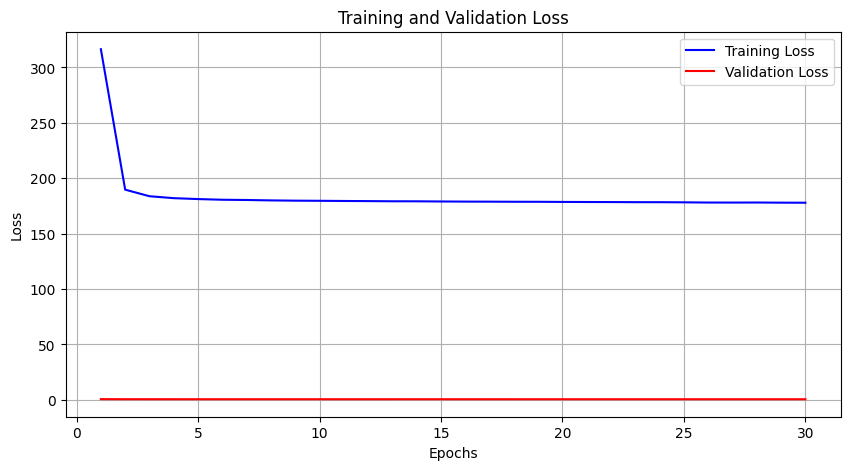

In [8]:
#------------
#STEP 7
#---------- 

import os
import gc
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  # Importing matplotlib for plotting

from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# -------------------------
# Paths
# -------------------------
STEP4_DIR = "/kaggle/working/step4_outputs"
STEP7_DIR = "/kaggle/working/step7_outputs"
os.makedirs(STEP7_DIR, exist_ok=True)

CERT_SESSIONS = os.path.join(STEP4_DIR, "cert_sessions.parquet")
CIC_SESSION_DIR = os.path.join(STEP4_DIR, "cic_sessions")

MODEL_PATH = os.path.join(STEP7_DIR, "intent_model_fast.pt")
VOCAB_PATH = os.path.join(STEP7_DIR, "vocab.json")

# -------------------------
# Intent mapping (same)
# -------------------------
def map_cert_intent(seq):
    last = seq[-1]
    if last in ["authentication_logon", "authentication_logoff"]:
        return "authentication"
    if last in ["file_read"]:
        return "collection"
    if last in ["file_copy", "file_write"]:
        return "exfiltration_prep"
    if last in ["file_delete"]:
        return "cover_tracks"
    return "other"

def map_cic_intent(seq):
    last = seq[-1]
    if last in ["scan_like"]:
        return "reconnaissance"
    if last in ["syn_like", "reset_anomaly"]:
        return "disruption"
    if last in ["bulk_transfer"]:
        return "exfiltration"
    if last in ["interactive"]:
        return "command_control"
    return "benign"

# -------------------------
# Load SMALL sample (important)
# -------------------------
def load_sessions():

    cert_df = pd.read_parquet(CERT_SESSIONS)
    cert_df = cert_df.sample(n=20000, random_state=42)
    cert_df["intent"] = cert_df["sequence"].apply(map_cert_intent)

    cic_parts = []
    for f in os.listdir(CIC_SESSION_DIR):
        df = pd.read_parquet(os.path.join(CIC_SESSION_DIR, f))
        df = df.sample(n=min(5000, len(df)), random_state=42)
        df["intent"] = df["sequence"].apply(map_cic_intent)
        cic_parts.append(df)

    cic_df = pd.concat(cic_parts, ignore_index=True)

    return pd.concat([cert_df, cic_df], ignore_index=True)

df = load_sessions()
print("Dataset size:", len(df))

# -------------------------
# Vocabulary
# -------------------------
tokens = set()
for seq in df["sequence"]:
    tokens.update(seq)

vocab = {t:i+1 for i,t in enumerate(sorted(tokens))}
vocab["<PAD>"] = 0

with open(VOCAB_PATH, "w") as f:
    json.dump(vocab, f)

intent_labels = sorted(df["intent"].unique())
intent_map = {k:i for i,k in enumerate(intent_labels)}

# -------------------------
# Dataset
# -------------------------
MAX_LEN = 30

class SeqDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        seq = self.df.iloc[idx]["sequence"]
        intent = self.df.iloc[idx]["intent"]

        enc = [vocab.get(x,0) for x in seq][:MAX_LEN]
        enc += [0]*(MAX_LEN-len(enc))

        return torch.tensor(enc), torch.tensor(intent_map[intent])

loader = DataLoader(SeqDataset(df), batch_size=128, shuffle=True)

# -------------------------
# FAST MODEL
# -------------------------
class FastModel(nn.Module):
    def __init__(self, vocab_size, num_classes):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, 32)
        self.fc = nn.Linear(32, num_classes)

    def forward(self, x):
        x = self.embed(x)            # (B, L, 32)
        x = x.mean(dim=1)            # average pooling
        return self.fc(x)

model = FastModel(len(vocab), len(intent_map))

# -------------------------
# Optimizer, Loss, Scheduler
# -------------------------
optimizer = Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

# Learning Rate Scheduler
scheduler = ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

# -------------------------
# Train with Early Stopping & Validation Split
# -------------------------
EPOCHS = 30
best_val_loss = float('inf')
patience = 5
epochs_no_improve = 0

# Validation split (80-20 split)
train_size = int(0.8 * len(df))
train_df, val_df = df[:train_size], df[train_size:]

train_loader = DataLoader(SeqDataset(train_df), batch_size=128, shuffle=True)
val_loader = DataLoader(SeqDataset(val_df), batch_size=128, shuffle=False)

# For storing loss values for plotting curves
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        optimizer.zero_grad()
        out = model(x)
        loss = loss_fn(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    # Validation loss
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            out = model(x)
            loss = loss_fn(out, y)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    print(f"Epoch {epoch+1} Loss: {total_loss} | Validation Loss: {avg_val_loss}")

    # Append losses for plotting
    train_losses.append(total_loss)
    val_losses.append(avg_val_loss)

    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        # Save model checkpoint
        torch.save(model.state_dict(), MODEL_PATH)
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print("Early stopping")
        break

    # Learning rate decay
    scheduler.step(avg_val_loss)

# -------------------------
# Final Save
# -------------------------
torch.save(model.state_dict(), MODEL_PATH)
print("\nSaved final model:", MODEL_PATH)
print("\n STEP 7 COMPLETE (FAST)")

# -------------------------
# Plot Training and Validation Curves
# -------------------------
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses)+1), train_losses, label="Training Loss", color="blue")
plt.plot(range(1, len(val_losses)+1), val_losses, label="Validation Loss", color="red")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
import os
import json
import torch
import pandas as pd
import numpy as np
from torch import nn

STEP4_DIR = "/kaggle/working/step4_outputs"
STEP7_DIR = "/kaggle/working/step7_outputs"
STEP8_DIR = "/kaggle/working/step8_outputs"

os.makedirs(STEP8_DIR, exist_ok=True)

CERT_PATH = os.path.join(STEP4_DIR, "cert_sessions.parquet")
CIC_DIR = os.path.join(STEP4_DIR, "cic_sessions")

# Update the model path to point to the correct location where the model is saved
MODEL_PATH = os.path.join(STEP7_DIR, "intent_model_fast.pt")
VOCAB_PATH = os.path.join(STEP7_DIR, "vocab.json")

OUTPUT_PATH = os.path.join(STEP8_DIR, "early_stage_predictions.parquet")

# -------------------------
# Load vocab
# -------------------------
with open(VOCAB_PATH) as f:
    vocab = json.load(f)

# -------------------------
# Rebuild Model to match Step 7 (feed-forward neural network with embedding layer and 9 output classes)
# -------------------------
class Model(nn.Module):
    def __init__(self, vocab_size, num_classes=9):  # Output size now 9 for multi-class classification
        super().__init__()
        self.emb = nn.Embedding(vocab_size, 32)
        self.fc = nn.Linear(32, num_classes)  # Fully connected layer with 9 output units

    def forward(self, x):
        x = self.emb(x)
        x = x.mean(dim=1)  # Mean pooling across sequence length
        return self.fc(x)

model = Model(len(vocab), num_classes=9)  # Adjust output to 9 classes

# -------------------------
# Load the model state_dict
# -------------------------
checkpoint = torch.load(MODEL_PATH)
model_state_dict = {k: v for k, v in checkpoint.items() if k in model.state_dict()}
model.load_state_dict(model_state_dict, strict=False)
model.eval()

# -------------------------
# Utils
# -------------------------
def ensure_list(seq):
    if isinstance(seq, list):
        return seq
    if isinstance(seq, (tuple, np.ndarray)):
        return list(seq)
    return None

def encode(seq):
    MAX_LEN = 12
    enc = [vocab.get(x, 0) for x in seq][:MAX_LEN]
    enc += [0]*(MAX_LEN-len(enc))
    return enc

# -------------------------
# Build small inference dataset
# -------------------------
df = pd.read_parquet(CERT_PATH).sample(n=15000, random_state=42)

rows = []
for seq in df["sequence"]:
    seq = ensure_list(seq)
    if seq and len(seq) >= 6:
        prefix = seq[:6]
        rows.append(encode(prefix))

X = torch.tensor(rows, dtype=torch.long)

# -------------------------
# Predict
# -------------------------
with torch.no_grad():
    logits = model(X)
    probs = torch.softmax(logits, dim=1)  # Probability distribution over all 9 classes

# Get the max probability for each sample and its corresponding class
pred_class = probs.argmax(dim=1).numpy()  # Get the class with max probability
pred_prob = probs.max(dim=1).values.numpy()  # Extract the max probability

# Prepare the output dataframe
out_df = pd.DataFrame({
    "pred_early_attack_prob": pred_prob,
    "early_attack_label": pred_class  # Multi-class output: label corresponds to the class with max probability
})

# -------------------------
# Save predictions to parquet file
# -------------------------
out_df.to_parquet(OUTPUT_PATH, index=False)

print("Saved:", OUTPUT_PATH)
print("Rows:", len(out_df))
print("\n✅ STEP 8 PREDICTIONS FIXED")

Saved: /kaggle/working/step8_outputs/early_stage_predictions.parquet
Rows: 15000

✅ STEP 8 PREDICTIONS FIXED


In [10]:
#---------
#step 8.5
#----------
import os
import gc
import json
import numpy as np
import pandas as pd
import torch
from torch import nn

STEP4_DIR = "/kaggle/working/step4_outputs"
STEP7_DIR = "/kaggle/working/step7_outputs"
STEP8_DIR = "/kaggle/working/step8_outputs"
STEP85_DIR = "/kaggle/working/step85_outputs"
os.makedirs(STEP85_DIR, exist_ok=True)

CERT_SESSIONS_PATH = os.path.join(STEP4_DIR, "cert_sessions.parquet")
CIC_SESSIONS_DIR = os.path.join(STEP4_DIR, "cic_sessions")
VOCAB_PATH = os.path.join(STEP7_DIR, "vocab.json")

# Correcting the model path to point to the right location
MODEL_PATH = os.path.join(STEP7_DIR, "intent_model_fast.pt")

OUTPUT_PATH = os.path.join(STEP85_DIR, "open_set_results.parquet")
SUMMARY_PATH = os.path.join(STEP85_DIR, "step85_summary.json")

# -------------------------
# Utils
# -------------------------
def free_memory(*objs):
    for obj in objs:
        try:
            del obj
        except:
            pass
    gc.collect()

def ensure_list(seq):
    if isinstance(seq, list):
        return seq
    if isinstance(seq, (tuple, np.ndarray)):
        return list(seq)
    return None

def prefix_intent_cert(seq):
    last = seq[-1]
    if last in ["authentication_logon", "authentication_logoff"]:
        return "authentication"
    if last in ["file_read"]:
        return "collection"
    if last in ["file_copy", "file_write"]:
        return "exfiltration_prep"
    if last in ["file_delete"]:
        return "cover_tracks"
    return "other"

def prefix_intent_cic(seq):
    last = seq[-1]
    if last in ["scan_like"]:
        return "reconnaissance"
    if last in ["syn_like", "reset_anomaly"]:
        return "disruption"
    if last in ["bulk_transfer"]:
        return "exfiltration"
    if last in ["interactive"]:
        return "command_control"
    return "benign"

def is_attack(intent):
    return int(intent not in ["authentication", "benign", "other", "unknown"])

# -------------------------
# Load vocab
# -------------------------
with open(VOCAB_PATH, "r") as f:
    vocab = json.load(f)

MAX_LEN = 12

def encode(seq):
    enc = [vocab.get(x, 0) for x in seq][:MAX_LEN]
    enc += [0] * (MAX_LEN - len(enc))
    return enc

# -------------------------
# Rebuild model from Step 7 with 9 output classes
# -------------------------
class Model(nn.Module):
    def __init__(self, vocab_size, num_classes=9):  # Output size now 9 for multi-class classification
        super().__init__()
        self.emb = nn.Embedding(vocab_size, 32)
        self.fc = nn.Linear(32, num_classes)  # Output layer now has 9 units

    def forward(self, x):
        x = self.emb(x)
        x = x.mean(dim=1)  # Mean pooling across sequence length
        return self.fc(x)

model = Model(len(vocab), num_classes=9)  # Adjust output to 9 classes

# -------------------------
# Load the model state_dict
# -------------------------
checkpoint = torch.load(MODEL_PATH, map_location="cpu")

# Remove unnecessary keys from the checkpoint (e.g., "model_state", "intent_map")
model_state_dict = {k: v for k, v in checkpoint.items() if k in model.state_dict()}

# Load the filtered state_dict into the model
model.load_state_dict(model_state_dict, strict=False)
model.eval()

# -------------------------
# Build mixed calibration dataset
# -------------------------
def build_cert_open_set(max_rows=8000):
    df = pd.read_parquet(CERT_SESSIONS_PATH)
    if len(df) > max_rows:
        df = df.sample(n=max_rows, random_state=42).reset_index(drop=True)

    rows = []
    for seq in df["sequence"]:
        seq = ensure_list(seq)
        if seq is None or len(seq) < 6:
            continue
        prefix_len = max(5, int(len(seq) * 0.3))
        prefix_len = min(prefix_len, len(seq) - 1)
        prefix = seq[:prefix_len]
        intent = prefix_intent_cert(prefix)
        rows.append({
            "source": "cert",
            "prefix": prefix,
            "intent": intent,
            "label": is_attack(intent)
        })
    return pd.DataFrame(rows)

def build_cic_open_set(max_per_file=1500):
    rows = []
    files = sorted([f for f in os.listdir(CIC_SESSIONS_DIR) if f.endswith(".parquet")])

    for fname in files:
        df = pd.read_parquet(os.path.join(CIC_SESSIONS_DIR, fname))
        if len(df) > max_per_file:
            df = df.sample(n=max_per_file, random_state=42).reset_index(drop=True)

        for seq in df["sequence"]:
            seq = ensure_list(seq)
            if seq is None or len(seq) < 6:
                continue
            prefix_len = max(5, int(len(seq) * 0.3))
            prefix_len = min(prefix_len, len(seq) - 1)
            prefix = seq[:prefix_len]
            intent = prefix_intent_cic(prefix)
            rows.append({
                "source": "cic",
                "file": fname,
                "prefix": prefix,
                "intent": intent,
                "label": is_attack(intent)
            })

        free_memory(df)

    return pd.DataFrame(rows)

print("[INFO] Building mixed open-set calibration data...")
cert_df = build_cert_open_set()
cic_df = build_cic_open_set()
df = pd.concat([cert_df, cic_df], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Calibration dataset size:", len(df))
print("Source distribution:", df["source"].value_counts().to_dict())
print("Attack label distribution:", df["label"].value_counts().to_dict())

# -------------------------
# Score model
# -------------------------
encoded = np.array([encode(seq) for seq in df["prefix"]], dtype=np.int64)
X = torch.tensor(encoded, dtype=torch.long)

with torch.no_grad():
    logits = model(X)
    probs = torch.softmax(logits, dim=1).numpy()
    p_attack = probs[:, 1]
    pred_cls = np.argmax(probs, axis=1)
    confidence = probs.max(axis=1)

df["prob_attack"] = p_attack
df["pred_class"] = pred_cls
df["confidence"] = confidence

# -------------------------
# Calibrated UNKNOWN gating
# Use middle-confidence band as UNKNOWN
# -------------------------
low_conf = float(np.quantile(df["confidence"], 0.35))
high_conf = float(np.quantile(df["confidence"], 0.75))

def classify_open_set(conf, pred):
    if low_conf <= conf <= high_conf:
        return "unknown"
    return "attack" if pred == 1 else "benign"

df["open_set_label"] = [
    classify_open_set(c, p) for c, p in zip(df["confidence"], df["pred_class"])
]

# -------------------------
# Summary
# -------------------------
counts = df["open_set_label"].value_counts().to_dict()

summary = {
    "total_samples": int(len(df)),
    "source_distribution": {str(k): int(v) for k, v in df["source"].value_counts().to_dict().items()},
    "attack_label_distribution": {str(k): int(v) for k, v in df["label"].value_counts().to_dict().items()},
    "calibrated_thresholds": {
        "low_conf_quantile_35": low_conf,
        "high_conf_quantile_75": high_conf
    },
    "open_set_distribution": {str(k): int(v) for k, v in counts.items()},
    "unknown_ratio": float(counts.get("unknown", 0) / max(len(df), 1))
}

df.to_parquet(OUTPUT_PATH, index=False)

with open(SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("\nCalibrated thresholds:", summary["calibrated_thresholds"])
print("Open-set distribution:", summary["open_set_distribution"])
print("Unknown ratio:", summary["unknown_ratio"])
print("\nSaved:", OUTPUT_PATH)
print("Saved:", SUMMARY_PATH)
print("\n✅ STEP 8.5 COMPLETE (CALIBRATED)")

[INFO] Building mixed open-set calibration data...
Calibration dataset size: 20000
Source distribution: {'cic': 12000, 'cert': 8000}
Attack label distribution: {0: 13353, 1: 6647}

Calibrated thresholds: {'low_conf_quantile_35': 0.2829243838787079, 'high_conf_quantile_75': 0.3153631091117859}
Open-set distribution: {'benign': 11056, 'unknown': 8944}
Unknown ratio: 0.4472

Saved: /kaggle/working/step85_outputs/open_set_results.parquet
Saved: /kaggle/working/step85_outputs/step85_summary.json

✅ STEP 8.5 COMPLETE (CALIBRATED)


In [11]:
# =========================
# STEP 9: MOVEMENT FORECASTING (FINAL CORRECTED)
# =========================

import os
import gc
import json
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

# -------------------------
# Paths
# -------------------------
STEP5_DIR = "/kaggle/working/step5_outputs"
STEP9_DIR = "/kaggle/working/step9_outputs"
os.makedirs(STEP9_DIR, exist_ok=True)

CERT_EDGE_PATH = os.path.join(STEP5_DIR, "cert_graph_edges.parquet")
CIC_EDGE_DIR = os.path.join(STEP5_DIR, "cic_graph_edges")

MODEL_PATH = os.path.join(STEP9_DIR, "movement_model.pt")
PRED_PATH = os.path.join(STEP9_DIR, "movement_predictions.parquet")
SUMMARY_PATH = os.path.join(STEP9_DIR, "step9_summary.json")

# -------------------------
# Utils
# -------------------------
def free_memory(*objs):
    for obj in objs:
        try:
            del obj
        except:
            pass
    gc.collect()

def safe_series(df, col, fill=0.0):
    if col not in df.columns:
        return pd.Series([fill] * len(df), index=df.index)
    return pd.to_numeric(df[col], errors="coerce").fillna(fill)

def safe_text(df, col, fill="unknown"):
    if col not in df.columns:
        return pd.Series([fill] * len(df), index=df.index)
    return df[col].fillna(fill).astype(str)

def add_degree_features(df, src_col="src_id", dst_col="dst_id", weight_col="f_weight"):
    src_deg = df.groupby(src_col).size().rename("src_degree")
    dst_deg = df.groupby(dst_col).size().rename("dst_degree")
    src_wsum = df.groupby(src_col)[weight_col].sum().rename("src_weight_sum")
    dst_wsum = df.groupby(dst_col)[weight_col].sum().rename("dst_weight_sum")

    df = df.merge(src_deg, left_on=src_col, right_index=True, how="left")
    df = df.merge(dst_deg, left_on=dst_col, right_index=True, how="left")
    df = df.merge(src_wsum, left_on=src_col, right_index=True, how="left")
    df = df.merge(dst_wsum, left_on=dst_col, right_index=True, how="left")

    df["src_degree"] = df["src_degree"].fillna(0)
    df["dst_degree"] = df["dst_degree"].fillna(0)
    df["src_weight_sum"] = df["src_weight_sum"].fillna(0.0)
    df["dst_weight_sum"] = df["dst_weight_sum"].fillna(0.0)

    df["f_src_degree"] = df["src_degree"].astype(float)
    df["f_dst_degree"] = df["dst_degree"].astype(float)
    df["f_src_weight_sum"] = df["src_weight_sum"].astype(float)
    df["f_dst_weight_sum"] = df["dst_weight_sum"].astype(float)
    df["f_weight_over_src_total"] = np.where(df["src_weight_sum"] > 0, df[weight_col] / df["src_weight_sum"], 0.0)
    df["f_weight_over_dst_total"] = np.where(df["dst_weight_sum"] > 0, df[weight_col] / df["dst_weight_sum"], 0.0)

    df = df.drop(columns=["src_degree", "dst_degree", "src_weight_sum", "dst_weight_sum"])
    return df

# -------------------------
# CERT feature builder
# -------------------------
def build_cert_features(max_rows=120000):
    df = pd.read_parquet(CERT_EDGE_PATH)

    if len(df) > max_rows:
        df = df.sample(n=max_rows, random_state=42).reset_index(drop=True)

    weight = safe_series(df, "weight", 1.0)
    edge_type = safe_text(df, "edge_type")
    edge_family = safe_text(df, "edge_family")
    source_table = safe_text(df, "source_table")
    src_id = safe_text(df, "src_id")
    dst_id = safe_text(df, "dst_id")

    out = pd.DataFrame({
        "source": "cert",
        "src_id": src_id,
        "dst_id": dst_id,
        "f_weight": weight.astype(float),
        "f_log_weight": np.log1p(weight).astype(float),
        "f_same_src_dst": (src_id == dst_id).astype(float),
        "f_is_file_family": (edge_family == "file_activity").astype(float),
        "f_is_logon_table": (source_table == "logon").astype(float),
    })

    out = add_degree_features(out, "src_id", "dst_id", "f_weight")

    # target only
    out["movement_label"] = edge_type.isin(["file_copy", "file_write", "file_delete"]).astype(int)

    return out

# -------------------------
# CIC feature builder
# -------------------------
def build_cic_features(max_per_file=30000):
    rows = []

    files = sorted([f for f in os.listdir(CIC_EDGE_DIR) if f.endswith(".parquet")])

    for fname in files:
        df = pd.read_parquet(os.path.join(CIC_EDGE_DIR, fname))

        if len(df) > max_per_file:
            df = df.sample(n=max_per_file, random_state=42).reset_index(drop=True)

        weight = safe_series(df, "weight", 1.0)
        avg_packets = safe_series(df, "avg_total_packets", 0.0)
        avg_bytes = safe_series(df, "avg_total_bytes", 0.0)
        avg_pkt_rate = safe_series(df, "avg_flow_packets_per_sec", 0.0)
        avg_byte_rate = safe_series(df, "avg_flow_bytes_per_sec", 0.0)

        label = safe_text(df, "label")
        protocol = safe_text(df, "protocol_std")
        src_id = safe_text(df, "src_id")
        dst_id = safe_text(df, "dst_id")

        out = pd.DataFrame({
            "source": "cic",
            "file": fname,
            "src_id": src_id,
            "dst_id": dst_id,
            "f_weight": weight.astype(float),
            "f_log_weight": np.log1p(weight).astype(float),
            "f_avg_packets": avg_packets.astype(float),
            "f_avg_bytes": avg_bytes.astype(float),
            "f_avg_pkt_rate": avg_pkt_rate.astype(float),
            "f_avg_byte_rate": avg_byte_rate.astype(float),
            "f_bytes_per_packet": np.where(avg_packets > 0, avg_bytes / np.maximum(avg_packets, 1e-6), 0.0),
            "f_pkt_byte_ratio": np.where(avg_bytes > 0, avg_packets / np.maximum(avg_bytes, 1e-6), 0.0),
            "f_is_tcp_like": protocol.str.contains("6|tcp", case=False, regex=True).astype(float),
            "f_is_udp_like": protocol.str.contains("17|udp", case=False, regex=True).astype(float),
        })

        out = add_degree_features(out, "src_id", "dst_id", "f_weight")

        # target only
        out["movement_label"] = (label != "benign").astype(int)

        rows.append(out)
        free_memory(df, out)

    return pd.concat(rows, ignore_index=True)

print("[INFO] Building movement dataset...")

cert_df = build_cert_features()
cic_df = build_cic_features()

full_df = pd.concat([cert_df, cic_df], ignore_index=True)
full_df = full_df.sample(frac=1.0, random_state=42).reset_index(drop=True)

print("Movement dataset size:", len(full_df))
print("Source distribution:", full_df["source"].value_counts().to_dict())
print("Movement label distribution:", full_df["movement_label"].value_counts().to_dict())

# -------------------------
# Features
# -------------------------
feature_cols = [c for c in full_df.columns if c.startswith("f_")]

for c in feature_cols:
    full_df[c] = pd.to_numeric(full_df[c], errors="coerce").fillna(0.0)

for c in feature_cols:
    mean = full_df[c].mean()
    std = full_df[c].std()
    if std and std > 1e-8:
        full_df[c] = (full_df[c] - mean) / std
    else:
        full_df[c] = 0.0

# -------------------------
# Split
# -------------------------
split_idx = int(0.8 * len(full_df))
train_df = full_df.iloc[:split_idx].reset_index(drop=True)
valid_df = full_df.iloc[split_idx:].reset_index(drop=True)

# Balanced training subset only
pos_train = train_df[train_df["movement_label"] == 1]
neg_train = train_df[train_df["movement_label"] == 0]

n_pos = len(pos_train)
n_neg_keep = min(len(neg_train), n_pos * 2)   # 1:2 positive:negative
neg_train_bal = neg_train.sample(n=n_neg_keep, random_state=42)

train_bal = pd.concat([pos_train, neg_train_bal], ignore_index=True)
train_bal = train_bal.sample(frac=1.0, random_state=42).reset_index(drop=True)

print("Train size (raw):", len(train_df))
print("Train size (balanced):", len(train_bal))
print("Valid size:", len(valid_df))
print("Balanced train label distribution:", train_bal["movement_label"].value_counts().to_dict())
print("Feature columns:", feature_cols)

# -------------------------
# Dataset
# -------------------------
class MovementDataset(Dataset):
    def __init__(self, df, feature_cols):
        self.X = df[feature_cols].values.astype(np.float32)
        self.y = df["movement_label"].astype(np.float32).values

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.X[idx], dtype=torch.float32),
            torch.tensor(self.y[idx], dtype=torch.float32)
        )

train_loader = DataLoader(MovementDataset(train_bal, feature_cols), batch_size=256, shuffle=True)
valid_loader = DataLoader(MovementDataset(valid_df, feature_cols), batch_size=512, shuffle=False)

# -------------------------
# Model
# -------------------------
class MovementNet(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

model = MovementNet(len(feature_cols))
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# -------------------------
# Metrics
# -------------------------
def metrics_at_threshold(y_true, probs, thr):
    preds = (probs >= thr).astype(int)

    tp = int(((preds == 1) & (y_true == 1)).sum())
    tn = int(((preds == 0) & (y_true == 0)).sum())
    fp = int(((preds == 1) & (y_true == 0)).sum())
    fn = int(((preds == 0) & (y_true == 1)).sum())

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-8)
    accuracy = (tp + tn) / max(len(y_true), 1)

    return {
        "tp": tp, "tn": tn, "fp": fp, "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy,
        "threshold": thr
    }

def evaluate_collect(model, loader):
    model.eval()
    probs_all = []
    y_all = []

    with torch.no_grad():
        for x, y in loader:
            logits = model(x)
            probs = torch.sigmoid(logits).cpu().numpy()
            probs_all.extend(probs.tolist())
            y_all.extend(y.cpu().numpy().astype(int).tolist())

    return np.array(y_all), np.array(probs_all)

# -------------------------
# Train
# -------------------------
print("\n[INFO] Training movement model...")

EPOCHS = 30
best_threshold = 0.5
best_epoch_metrics = None

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    for x, y in train_loader:
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    y_val, p_val = evaluate_collect(model, valid_loader)

    threshold_grid = np.arange(0.45, 0.91, 0.05)
    epoch_best = None
    for thr in threshold_grid:
        m = metrics_at_threshold(y_val, p_val, thr)
        if epoch_best is None or m["f1"] > epoch_best["f1"]:
            epoch_best = m

    best_threshold = epoch_best["threshold"]
    best_epoch_metrics = epoch_best

    print(
        f"Epoch {epoch+1} | Loss={total_loss:.2f} | "
        f"BestThr={best_threshold:.2f} | "
        f"Acc={epoch_best['accuracy']:.4f} | "
        f"F1={epoch_best['f1']:.4f} | "
        f"Precision={epoch_best['precision']:.4f} | "
        f"Recall={epoch_best['recall']:.4f}"
    )

# -------------------------
# Final evaluation
# -------------------------
y_val, p_val = evaluate_collect(model, valid_loader)
final_metrics = metrics_at_threshold(y_val, p_val, best_threshold)

pred_df = valid_df.copy()
pred_df["pred_movement_prob"] = p_val
pred_df["pred_movement"] = (p_val >= best_threshold).astype(int)
pred_df.to_parquet(PRED_PATH, index=False)

torch.save({
    "model_state": model.state_dict(),
    "feature_cols": feature_cols,
    "best_threshold": float(best_threshold)
}, MODEL_PATH)

summary = {
    "dataset_size": int(len(full_df)),
    "train_size_raw": int(len(train_df)),
    "train_size_balanced": int(len(train_bal)),
    "valid_size": int(len(valid_df)),
    "source_distribution": {str(k): int(v) for k, v in full_df["source"].value_counts().to_dict().items()},
    "label_distribution": {str(k): int(v) for k, v in full_df["movement_label"].value_counts().to_dict().items()},
    "feature_cols": feature_cols,
    "best_threshold": float(best_threshold),
    "metrics": {
        "tp": int(final_metrics["tp"]),
        "tn": int(final_metrics["tn"]),
        "fp": int(final_metrics["fp"]),
        "fn": int(final_metrics["fn"]),
        "precision": float(final_metrics["precision"]),
        "recall": float(final_metrics["recall"]),
        "f1": float(final_metrics["f1"]),
        "accuracy": float(final_metrics["accuracy"])
    }
}

with open(SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("\nSaved movement model:", MODEL_PATH)
print("Saved predictions:", PRED_PATH)
print("Saved summary:", SUMMARY_PATH)
print("\n✅ STEP 9 COMPLETE (FINAL CORRECTED)")



[INFO] Building movement dataset...
Movement dataset size: 360000
Source distribution: {'cic': 240000, 'cert': 120000}
Movement label distribution: {0: 312470, 1: 47530}
Train size (raw): 288000
Train size (balanced): 114288
Valid size: 72000
Balanced train label distribution: {0: 76192, 1: 38096}
Feature columns: ['f_weight', 'f_log_weight', 'f_same_src_dst', 'f_is_file_family', 'f_is_logon_table', 'f_src_degree', 'f_dst_degree', 'f_src_weight_sum', 'f_dst_weight_sum', 'f_weight_over_src_total', 'f_weight_over_dst_total', 'f_avg_packets', 'f_avg_bytes', 'f_avg_pkt_rate', 'f_avg_byte_rate', 'f_bytes_per_packet', 'f_pkt_byte_ratio', 'f_is_tcp_like', 'f_is_udp_like']

[INFO] Training movement model...
Epoch 1 | Loss=228.09 | BestThr=0.45 | Acc=0.8781 | F1=0.2270 | Precision=0.6707 | Recall=0.1366
Epoch 2 | Loss=222.69 | BestThr=0.55 | Acc=0.8785 | F1=0.2274 | Precision=0.6828 | Recall=0.1364
Epoch 3 | Loss=222.42 | BestThr=0.50 | Acc=0.8784 | F1=0.2275 | Precision=0.6791 | Recall=0.1366


In [12]:
# =========================
# STEP 10: HYBRID INTEGRATION (Transformer + Movement Model)
# =========================

import os
import gc
import json
import numpy as np
import pandas as pd

# -------------------------
# Paths
# -------------------------
STEP8_DIR = "/kaggle/working/step8_outputs"
STEP85_DIR = "/kaggle/working/step85_outputs"
STEP9_DIR = "/kaggle/working/step9_outputs"
STEP10_DIR = "/kaggle/working/step10_outputs"
os.makedirs(STEP10_DIR, exist_ok=True)

STEP8_SUMMARY_PATH = os.path.join(STEP8_DIR, "step8_summary.json")
STEP85_SUMMARY_PATH = os.path.join(STEP85_DIR, "step85_summary.json")
STEP9_SUMMARY_PATH = os.path.join(STEP9_DIR, "step9_summary.json")

STEP8_PRED_PATH = os.path.join(STEP8_DIR, "early_stage_predictions.parquet")
STEP9_PRED_PATH = os.path.join(STEP9_DIR, "movement_predictions.parquet")
STEP85_OPEN_PATH = os.path.join(STEP85_DIR, "open_set_results.parquet")

HYBRID_OUTPUT_PATH = os.path.join(STEP10_DIR, "hybrid_predictions.parquet")
HYBRID_SUMMARY_PATH = os.path.join(STEP10_DIR, "step10_summary.json")

# -------------------------
# Utils
# -------------------------
def safe_read_json(path):
    try:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    except FileNotFoundError:
        print(f"[WARN] {path} not found. Skipping file.")
        return {}

def minmax01(x):
    x = pd.to_numeric(x, errors="coerce").fillna(0.0)
    xmin = x.min()
    xmax = x.max()
    if xmax - xmin < 1e-12:
        return pd.Series(np.zeros(len(x)), index=x.index)
    return (x - xmin) / (xmax - xmin)

# -------------------------
# Load inputs
# -------------------------
step8_summary = safe_read_json(STEP8_SUMMARY_PATH)
step85_summary = safe_read_json(STEP85_SUMMARY_PATH)
step9_summary = safe_read_json(STEP9_SUMMARY_PATH)

step8_df = pd.read_parquet(STEP8_PRED_PATH)
step9_df = pd.read_parquet(STEP9_PRED_PATH)
open_df = pd.read_parquet(STEP85_OPEN_PATH)

print("[INFO] Loaded:")
print(" - Step 8 rows :", len(step8_df))
print(" - Step 9 rows :", len(step9_df))
print(" - Step 8.5 rows:", len(open_df))

# -------------------------
# Normalize prediction columns
# -------------------------
# Step 8
if "pred_early_attack_prob" in step8_df.columns:
    step8_df["early_prob"] = pd.to_numeric(step8_df["pred_early_attack_prob"], errors="coerce").fillna(0.0)
elif "prob_attack" in step8_df.columns:
    step8_df["early_prob"] = pd.to_numeric(step8_df["prob_attack"], errors="coerce").fillna(0.0)
else:
    step8_df["early_prob"] = 0.0

if "early_attack_label" in step8_df.columns:
    step8_df["early_true"] = pd.to_numeric(step8_df["early_attack_label"], errors="coerce").fillna(0).astype(int)
elif "label" in step8_df.columns:
    step8_df["early_true"] = pd.to_numeric(step8_df["label"], errors="coerce").fillna(0).astype(int)
else:
    step8_df["early_true"] = 0

# Step 9
if "pred_movement_prob" in step9_df.columns:
    step9_df["move_prob"] = pd.to_numeric(step9_df["pred_movement_prob"], errors="coerce").fillna(0.0)
else:
    step9_df["move_prob"] = 0.0

if "movement_label" in step9_df.columns:
    step9_df["move_true"] = pd.to_numeric(step9_df["movement_label"], errors="coerce").fillna(0).astype(int)
else:
    step9_df["move_true"] = 0

# Step 8.5
if "prob_attack" in open_df.columns:
    open_df["open_prob"] = pd.to_numeric(open_df["prob_attack"], errors="coerce").fillna(0.0)
else:
    open_df["open_prob"] = 0.0

if "open_set_label" not in open_df.columns:
    open_df["open_set_label"] = "unknown"

# -------------------------
# Align row counts safely
# Hybrid works on common minimum length
# -------------------------
n = min(len(step8_df), len(step9_df), len(open_df))
step8_df = step8_df.iloc[:n].reset_index(drop=True)
step9_df = step9_df.iloc[:n].reset_index(drop=True)
open_df = open_df.iloc[:n].reset_index(drop=True)

print("[INFO] Hybrid aligned rows:", n)

# -------------------------
# Build hybrid frame
# -------------------------
hybrid = pd.DataFrame({
    "early_prob": step8_df["early_prob"],
    "move_prob": step9_df["move_prob"],
    "open_prob": open_df["open_prob"],
    "open_set_label": open_df["open_set_label"].astype(str),
    "early_true": step8_df["early_true"],
    "move_true": step9_df["move_true"]
})

# Conservative joint target:
# event considered risky if either early-stage or movement ground truth is positive
hybrid["hybrid_true"] = ((hybrid["early_true"] == 1) | (hybrid["move_true"] == 1)).astype(int)

# -------------------------
# Confidence handling
# Penalize UNKNOWN from step 8.5
# -------------------------
unknown_penalty = np.where(hybrid["open_set_label"].eq("unknown"), 0.75, 1.0)
attack_boost = np.where(hybrid["open_set_label"].eq("attack"), 1.05, 1.0)
benign_penalty = np.where(hybrid["open_set_label"].eq("benign"), 0.95, 1.0)

# Blend signals
# Early model detects attack emergence
# Movement model detects graph transition risk
hybrid["hybrid_score_raw"] = (
    0.55 * hybrid["early_prob"] +
    0.45 * hybrid["move_prob"]
)

hybrid["hybrid_score_adjusted"] = (
    hybrid["hybrid_score_raw"] * unknown_penalty * attack_boost * benign_penalty
).clip(0.0, 1.0)

# Normalize adjusted score for stable thresholding
hybrid["hybrid_score"] = minmax01(hybrid["hybrid_score_adjusted"])

# -------------------------
# Threshold tuning for best F1
# -------------------------
def metrics_at_threshold(y_true, scores, thr):
    preds = (scores >= thr).astype(int)

    tp = int(((preds == 1) & (y_true == 1)).sum())
    tn = int(((preds == 0) & (y_true == 0)).sum())
    fp = int(((preds == 1) & (y_true == 0)).sum())
    fn = int(((preds == 0) & (y_true == 1)).sum())

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-8)
    accuracy = (tp + tn) / max(len(y_true), 1)

    return {
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy,
        "threshold": thr
    }

best = None
for thr in np.arange(0.20, 0.86, 0.05):
    m = metrics_at_threshold(hybrid["hybrid_true"].values, hybrid["hybrid_score"].values, thr)
    if best is None or m["f1"] > best["f1"]:
        best = m

best_thr = best["threshold"]
hybrid["hybrid_pred"] = (hybrid["hybrid_score"] >= best_thr).astype(int)

# -------------------------
# Save
# -------------------------
hybrid.to_parquet(HYBRID_OUTPUT_PATH, index=False)

summary = {
    "rows_used": int(len(hybrid)),
    "threshold": float(best_thr),
    "open_set_distribution": {str(k): int(v) for k, v in hybrid["open_set_label"].value_counts().to_dict().items()},
    "hybrid_true_distribution": {str(k): int(v) for k, v in hybrid["hybrid_true"].value_counts().to_dict().items()},
    "metrics": {
        "tp": int(best["tp"]),
        "tn": int(best["tn"]),
        "fp": int(best["fp"]),
        "fn": int(best["fn"]),
        "precision": float(best["precision"]),
        "recall": float(best["recall"]),
        "f1": float(best["f1"]),
        "accuracy": float(best["accuracy"])
    }
}

with open(HYBRID_SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("\nBest hybrid threshold:", best_thr)
print("Hybrid metrics:", summary["metrics"])
print("\nSaved:", HYBRID_OUTPUT_PATH)
print("Saved:", HYBRID_SUMMARY_PATH)
print("\n✅ STEP 10 COMPLETE")

[WARN] /kaggle/working/step8_outputs/step8_summary.json not found. Skipping file.
[INFO] Loaded:
 - Step 8 rows : 15000
 - Step 9 rows : 72000
 - Step 8.5 rows: 20000
[INFO] Hybrid aligned rows: 15000

Best hybrid threshold: 0.3
Hybrid metrics: {'tp': 1785, 'tn': 5578, 'fp': 7469, 'fn': 168, 'precision': 0.1928895612708018, 'recall': 0.9139784946236559, 'f1': 0.3185509056839475, 'accuracy': 0.4908666666666667}

Saved: /kaggle/working/step10_outputs/hybrid_predictions.parquet
Saved: /kaggle/working/step10_outputs/step10_summary.json

✅ STEP 10 COMPLETE


In [13]:
# =========================
# STEP 11: DEFENSE DECISION ENGINE (SIMULATION)
# =========================

import os
import json
import numpy as np
import pandas as pd

# -------------------------
# Paths
# -------------------------
STEP10_DIR = "/kaggle/working/step10_outputs"
STEP11_DIR = "/kaggle/working/step11_outputs"
os.makedirs(STEP11_DIR, exist_ok=True)

HYBRID_PRED_PATH = os.path.join(STEP10_DIR, "hybrid_predictions.parquet")
HYBRID_SUMMARY_PATH = os.path.join(STEP10_DIR, "step10_summary.json")

DECISION_OUTPUT_PATH = os.path.join(STEP11_DIR, "defense_decisions.parquet")
DECISION_SUMMARY_PATH = os.path.join(STEP11_DIR, "step11_summary.json")

# -------------------------
# Load
# -------------------------
hybrid_df = pd.read_parquet(HYBRID_PRED_PATH)

with open(HYBRID_SUMMARY_PATH, "r", encoding="utf-8") as f:
    hybrid_summary = json.load(f)

print("[INFO] Loaded hybrid rows:", len(hybrid_df))

# -------------------------
# Safety checks
# -------------------------
required_cols = ["hybrid_score", "hybrid_pred", "open_set_label"]
for c in required_cols:
    if c not in hybrid_df.columns:
        raise ValueError(f"Missing required column: {c}")

# -------------------------
# Decision rules
# -------------------------
# Interpretable simulation policy:
# - low score: allow
# - medium score: monitor
# - higher score: step-up auth / throttle
# - high score: isolate / block
#
# UNKNOWN acts as uncertainty penalty:
# - do not immediately isolate solely due to uncertainty
# - bias toward monitor / step-up unless score is already high

ALLOW_THRESHOLD = 0.20
MONITOR_THRESHOLD = 0.45
CHALLENGE_THRESHOLD = 0.65
ISOLATE_THRESHOLD = 0.82

def decide_action(score, open_label):
    # open-set adjustment
    if open_label == "unknown":
        if score < CHALLENGE_THRESHOLD:
            return "monitor"
        elif score < ISOLATE_THRESHOLD:
            return "step_up_auth"
        else:
            return "isolate_host"

    if open_label == "benign":
        if score < ALLOW_THRESHOLD:
            return "allow"
        elif score < MONITOR_THRESHOLD:
            return "monitor"
        elif score < CHALLENGE_THRESHOLD:
            return "step_up_auth"
        elif score < ISOLATE_THRESHOLD:
            return "throttle"
        else:
            return "isolate_host"

    # open_label == "attack"
    if score < MONITOR_THRESHOLD:
        return "monitor"
    elif score < CHALLENGE_THRESHOLD:
        return "step_up_auth"
    elif score < ISOLATE_THRESHOLD:
        return "throttle"
    else:
        return "isolate_host"

# -------------------------
# Cost model (simulation)
# -------------------------
# Lower is better.
# False positive heavy actions should cost more than monitor.
ACTION_COST = {
    "allow": 0.0,
    "monitor": 1.0,
    "step_up_auth": 3.0,
    "throttle": 6.0,
    "isolate_host": 10.0
}

# Attack mitigation value model
# Higher means stronger expected defense benefit.
ACTION_EFFECTIVENESS = {
    "allow": 0.0,
    "monitor": 0.20,
    "step_up_auth": 0.50,
    "throttle": 0.75,
    "isolate_host": 0.95
}

# -------------------------
# Apply decision engine
# -------------------------
df = hybrid_df.copy()

df["defense_action"] = [
    decide_action(score, label)
    for score, label in zip(df["hybrid_score"], df["open_set_label"])
]

df["action_cost"] = df["defense_action"].map(ACTION_COST).astype(float)
df["action_effectiveness"] = df["defense_action"].map(ACTION_EFFECTIVENESS).astype(float)

# Simulated utility:
# if true risky case -> effectiveness is reward
# if false alarm -> cost hurts more
df["is_true_risk"] = df["hybrid_true"].astype(int)

df["defense_utility"] = np.where(
    df["is_true_risk"] == 1,
    8.0 * df["action_effectiveness"] - df["action_cost"],
    -1.25 * df["action_cost"]
)

# Binary "intervention" flag
df["intervention_flag"] = df["defense_action"].isin(
    ["step_up_auth", "throttle", "isolate_host"]
).astype(int)

# -------------------------
# Metrics
# -------------------------
# Decision effectiveness as a control-policy evaluation
tp = int(((df["intervention_flag"] == 1) & (df["is_true_risk"] == 1)).sum())
tn = int(((df["intervention_flag"] == 0) & (df["is_true_risk"] == 0)).sum())
fp = int(((df["intervention_flag"] == 1) & (df["is_true_risk"] == 0)).sum())
fn = int(((df["intervention_flag"] == 0) & (df["is_true_risk"] == 1)).sum())

precision = tp / max(tp + fp, 1)
recall = tp / max(tp + fn, 1)
f1 = 2 * precision * recall / max(precision + recall, 1e-8)
accuracy = (tp + tn) / max(len(df), 1)

summary = {
    "rows": int(len(df)),
    "hybrid_threshold_used": float(hybrid_summary.get("threshold", -1)),
    "decision_thresholds": {
        "allow_threshold": ALLOW_THRESHOLD,
        "monitor_threshold": MONITOR_THRESHOLD,
        "challenge_threshold": CHALLENGE_THRESHOLD,
        "isolate_threshold": ISOLATE_THRESHOLD
    },
    "action_distribution": {str(k): int(v) for k, v in df["defense_action"].value_counts().to_dict().items()},
    "open_set_distribution": {str(k): int(v) for k, v in df["open_set_label"].value_counts().to_dict().items()},
    "intervention_metrics": {
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "accuracy": float(accuracy)
    },
    "avg_action_cost": float(df["action_cost"].mean()),
    "avg_action_effectiveness": float(df["action_effectiveness"].mean()),
    "avg_defense_utility": float(df["defense_utility"].mean())
}

# -------------------------
# Save
# -------------------------
df.to_parquet(DECISION_OUTPUT_PATH, index=False)

with open(DECISION_SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("\nAction distribution:", summary["action_distribution"])
print("Intervention metrics:", summary["intervention_metrics"])
print("Average cost:", summary["avg_action_cost"])
print("Average effectiveness:", summary["avg_action_effectiveness"])
print("Average utility:", summary["avg_defense_utility"])

print("\nSaved:", DECISION_OUTPUT_PATH)
print("Saved:", DECISION_SUMMARY_PATH)
print("\n✅ STEP 11 COMPLETE")

[INFO] Loaded hybrid rows: 15000

Action distribution: {'monitor': 8188, 'step_up_auth': 4095, 'allow': 2501, 'isolate_host': 169, 'throttle': 47}
Intervention metrics: {'tp': 920, 'tn': 9656, 'fp': 3391, 'fn': 1033, 'precision': 0.21340756205056832, 'recall': 0.47107014848950335, 'f1': 0.2937420178799489, 'accuracy': 0.7050666666666666}
Average cost: 1.4963333333333333
Average effectiveness: 0.2587266666666667
Average utility: -1.401943333333333

Saved: /kaggle/working/step11_outputs/defense_decisions.parquet
Saved: /kaggle/working/step11_outputs/step11_summary.json

✅ STEP 11 COMPLETE


In [14]:
# =========================
# STEP 12: EVIDENCE INTEGRITY ANCHORING
# Hash-chain + manifest anchoring for important artifacts
# =========================

import os
import json
import time
import hashlib
import pandas as pd

# -------------------------
# Paths
# -------------------------
STEP8_DIR  = "/kaggle/working/step8_outputs"
STEP85_DIR = "/kaggle/working/step85_outputs"
STEP9_DIR  = "/kaggle/working/step9_outputs"
STEP10_DIR = "/kaggle/working/step10_outputs"
STEP11_DIR = "/kaggle/working/step11_outputs"
STEP12_DIR = "/kaggle/working/step12_outputs"
os.makedirs(STEP12_DIR, exist_ok=True)

ANCHOR_TABLE_PATH   = os.path.join(STEP12_DIR, "evidence_anchor_table.parquet")
ANCHOR_LEDGER_PATH  = os.path.join(STEP12_DIR, "evidence_anchor_ledger.json")
ANCHOR_SUMMARY_PATH = os.path.join(STEP12_DIR, "step12_summary.json")

# -------------------------
# Files to anchor
# -------------------------
files_to_anchor = [
    os.path.join(STEP8_DIR,  "early_stage_predictions.parquet"),
    os.path.join(STEP85_DIR, "open_set_results.parquet"),
    os.path.join(STEP85_DIR, "step85_summary.json"),
    os.path.join(STEP9_DIR,  "movement_predictions.parquet"),
    os.path.join(STEP9_DIR,  "step9_summary.json"),
    os.path.join(STEP10_DIR, "hybrid_predictions.parquet"),
    os.path.join(STEP10_DIR, "step10_summary.json"),
    os.path.join(STEP11_DIR, "defense_decisions.parquet"),
    os.path.join(STEP11_DIR, "step11_summary.json"),
]

# -------------------------
# Utils
# -------------------------
def sha256_file(path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

def sha256_text(text):
    return hashlib.sha256(text.encode("utf-8")).hexdigest()

# -------------------------
# Build evidence records
# -------------------------
records = []
for path in files_to_anchor:
    if not os.path.exists(path):
        print(f"[WARN] Missing artifact, skipped: {path}")
        continue

    stat = os.stat(path)
    record = {
        "artifact_path": path,
        "artifact_name": os.path.basename(path),
        "file_size_bytes": int(stat.st_size),
        "modified_unix": float(stat.st_mtime),
        "modified_utc": pd.to_datetime(stat.st_mtime, unit="s", utc=True).isoformat(),
        "sha256": sha256_file(path)
    }
    records.append(record)

if len(records) == 0:
    raise ValueError("No artifacts found for anchoring.")

anchor_df = pd.DataFrame(records).sort_values(["artifact_name", "artifact_path"]).reset_index(drop=True)

# -------------------------
# Build chained ledger
# -------------------------
ledger = []
prev_hash = "GENESIS"

for i, row in anchor_df.iterrows():
    payload = {
        "index": int(i),
        "artifact_name": row["artifact_name"],
        "artifact_path": row["artifact_path"],
        "file_size_bytes": int(row["file_size_bytes"]),
        "modified_utc": row["modified_utc"],
        "sha256": row["sha256"],
        "prev_hash": prev_hash
    }

    payload_json = json.dumps(payload, sort_keys=True)
    record_hash = sha256_text(payload_json)

    ledger_item = dict(payload)
    ledger_item["record_hash"] = record_hash
    ledger.append(ledger_item)

    prev_hash = record_hash

anchor_root = prev_hash

# -------------------------
# Save
# -------------------------
anchor_df.to_parquet(ANCHOR_TABLE_PATH, index=False)

ledger_obj = {
    "created_utc": pd.Timestamp.utcnow().isoformat(),
    "num_artifacts": int(len(anchor_df)),
    "anchor_root": anchor_root,
    "ledger": ledger
}

with open(ANCHOR_LEDGER_PATH, "w", encoding="utf-8") as f:
    json.dump(ledger_obj, f, indent=2)

summary = {
    "num_artifacts": int(len(anchor_df)),
    "anchor_root": anchor_root,
    "anchored_files": anchor_df["artifact_name"].tolist()
}

with open(ANCHOR_SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("[INFO] Anchored artifacts:", len(anchor_df))
print("[INFO] Anchor root:", anchor_root)
print("[INFO] Saved:", ANCHOR_TABLE_PATH)
print("[INFO] Saved:", ANCHOR_LEDGER_PATH)
print("[INFO] Saved:", ANCHOR_SUMMARY_PATH)
print("\n✅ STEP 12 COMPLETE")

[INFO] Anchored artifacts: 9
[INFO] Anchor root: 32871deb21f5e5e2bd6365e2c7086d0ac86a9aa26eadde9059eda93a8e7fe11f
[INFO] Saved: /kaggle/working/step12_outputs/evidence_anchor_table.parquet
[INFO] Saved: /kaggle/working/step12_outputs/evidence_anchor_ledger.json
[INFO] Saved: /kaggle/working/step12_outputs/step12_summary.json

✅ STEP 12 COMPLETE


In [15]:
# =========================
# STEP 13: CROSS-DATASET EVALUATION
# Evaluate CERT vs CIC separately
# =========================

import os
import json
import numpy as np
import pandas as pd

# -------------------------
# Paths
# -------------------------
STEP10_DIR = "/kaggle/working/step10_outputs"
STEP11_DIR = "/kaggle/working/step11_outputs"
STEP85_DIR = "/kaggle/working/step85_outputs"
STEP13_DIR = "/kaggle/working/step13_outputs"
os.makedirs(STEP13_DIR, exist_ok=True)

HYBRID_PATH = os.path.join(STEP10_DIR, "hybrid_predictions.parquet")
DECISION_PATH = os.path.join(STEP11_DIR, "defense_decisions.parquet")
OPEN_PATH = os.path.join(STEP85_DIR, "open_set_results.parquet")

PER_SOURCE_METRICS_PATH = os.path.join(STEP13_DIR, "cross_dataset_metrics.csv")
PER_SOURCE_DECISION_PATH = os.path.join(STEP13_DIR, "cross_dataset_decision_metrics.csv")
SUMMARY_PATH = os.path.join(STEP13_DIR, "step13_summary.json")

# -------------------------
# Load
# -------------------------
hybrid_df = pd.read_parquet(HYBRID_PATH)
decision_df = pd.read_parquet(DECISION_PATH)
open_df = pd.read_parquet(OPEN_PATH)

n = min(len(hybrid_df), len(decision_df), len(open_df))
hybrid_df = hybrid_df.iloc[:n].reset_index(drop=True)
decision_df = decision_df.iloc[:n].reset_index(drop=True)
open_df = open_df.iloc[:n].reset_index(drop=True)

if "source" not in open_df.columns:
    raise ValueError("open_set_results.parquet must contain 'source' column for cross-dataset evaluation.")

eval_df = hybrid_df.copy()
eval_df["source"] = open_df["source"].astype(str).values
eval_df["defense_action"] = decision_df["defense_action"].astype(str).values
eval_df["intervention_flag"] = pd.to_numeric(decision_df["intervention_flag"], errors="coerce").fillna(0).astype(int)

# -------------------------
# Metrics util
# -------------------------
def binary_metrics(y_true, y_pred):
    y_true = pd.Series(y_true).astype(int).values
    y_pred = pd.Series(y_pred).astype(int).values

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-8)
    accuracy = (tp + tn) / max(len(y_true), 1)

    return {
        "tp": tp, "tn": tn, "fp": fp, "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy
    }

# -------------------------
# Hybrid prediction metrics by dataset
# -------------------------
hybrid_rows = []
decision_rows = []

for src, g in eval_df.groupby("source"):
    m1 = binary_metrics(g["hybrid_true"], g["hybrid_pred"])
    hybrid_rows.append({
        "source": src,
        "rows": int(len(g)),
        "positive_rate": float(pd.Series(g["hybrid_true"]).mean()),
        **m1
    })

    m2 = binary_metrics(g["hybrid_true"], g["intervention_flag"])
    decision_rows.append({
        "source": src,
        "rows": int(len(g)),
        "intervention_rate": float(pd.Series(g["intervention_flag"]).mean()),
        "avg_hybrid_score": float(pd.Series(g["hybrid_score"]).mean()),
        **m2
    })

hybrid_metrics_df = pd.DataFrame(hybrid_rows).sort_values("source").reset_index(drop=True)
decision_metrics_df = pd.DataFrame(decision_rows).sort_values("source").reset_index(drop=True)

hybrid_metrics_df.to_csv(PER_SOURCE_METRICS_PATH, index=False)
decision_metrics_df.to_csv(PER_SOURCE_DECISION_PATH, index=False)

summary = {
    "rows_evaluated": int(len(eval_df)),
    "sources": sorted(eval_df["source"].unique().tolist()),
    "hybrid_per_source": hybrid_metrics_df.to_dict(orient="records"),
    "decision_per_source": decision_metrics_df.to_dict(orient="records")
}

with open(SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("[INFO] Rows evaluated:", len(eval_df))
print("\n[HYBRID PER SOURCE]")
print(hybrid_metrics_df)
print("\n[DECISION PER SOURCE]")
print(decision_metrics_df)
print("\nSaved:", PER_SOURCE_METRICS_PATH)
print("Saved:", PER_SOURCE_DECISION_PATH)
print("Saved:", SUMMARY_PATH)
print("\n✅ STEP 13 COMPLETE")

[INFO] Rows evaluated: 15000

[HYBRID PER SOURCE]
  source  rows  positive_rate    tp    tn    fp  fn  precision    recall  \
0   cert  6008       0.128162   695  2295  2943  75   0.191039  0.902597   
1    cic  8992       0.131561  1090  3283  4526  93   0.194088  0.921386   

         f1  accuracy  
0  0.315336  0.497670  
1  0.320635  0.486321  

[DECISION PER SOURCE]
  source  rows  intervention_rate  avg_hybrid_score   tp    tn    fp   fn  \
0   cert  6008           0.254161          0.324971  319  4030  1208  451   
1    cic  8992           0.309609          0.338364  601  5626  2183  582   

   precision    recall        f1  accuracy  
0   0.208906  0.414286  0.277754  0.723868  
1   0.215876  0.508030  0.303000  0.692504  

Saved: /kaggle/working/step13_outputs/cross_dataset_metrics.csv
Saved: /kaggle/working/step13_outputs/cross_dataset_decision_metrics.csv
Saved: /kaggle/working/step13_outputs/step13_summary.json

✅ STEP 13 COMPLETE


In [16]:
# =========================
# STEP 14: METRICS & ABLATION STUDY
# Compare early-only, move-only, raw hybrid, calibrated hybrid
# =========================

import os
import json
import numpy as np
import pandas as pd

# -------------------------
# Paths
# -------------------------
STEP8_DIR  = "/kaggle/working/step8_outputs"
STEP9_DIR  = "/kaggle/working/step9_outputs"
STEP10_DIR = "/kaggle/working/step10_outputs"
STEP85_DIR = "/kaggle/working/step85_outputs"
STEP14_DIR = "/kaggle/working/step14_outputs"
os.makedirs(STEP14_DIR, exist_ok=True)

STEP8_PATH  = os.path.join(STEP8_DIR, "early_stage_predictions.parquet")
STEP9_PATH  = os.path.join(STEP9_DIR, "movement_predictions.parquet")
STEP10_PATH = os.path.join(STEP10_DIR, "hybrid_predictions.parquet")
OPEN_PATH   = os.path.join(STEP85_DIR, "open_set_results.parquet")

ABLATION_TABLE_PATH = os.path.join(STEP14_DIR, "ablation_metrics.csv")
SUMMARY_PATH = os.path.join(STEP14_DIR, "step14_summary.json")

# -------------------------
# Load
# -------------------------
step8_df = pd.read_parquet(STEP8_PATH)
step9_df = pd.read_parquet(STEP9_PATH)
hybrid_df = pd.read_parquet(STEP10_PATH)
open_df = pd.read_parquet(OPEN_PATH)

n = min(len(step8_df), len(step9_df), len(hybrid_df), len(open_df))
step8_df = step8_df.iloc[:n].reset_index(drop=True)
step9_df = step9_df.iloc[:n].reset_index(drop=True)
hybrid_df = hybrid_df.iloc[:n].reset_index(drop=True)
open_df = open_df.iloc[:n].reset_index(drop=True)

# -------------------------
# Column detection helpers
# -------------------------
def pick_col(df, candidates, required=True, default=None):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise ValueError(f"Missing expected columns. Tried: {candidates}. Available: {list(df.columns)}")
    return default

early_prob_col = pick_col(step8_df, ["pred_early_attack_prob", "early_attack_prob", "prob_early_attack"])
early_true_col = pick_col(step8_df, ["early_attack_label", "y_true", "label", "target"])

move_prob_col = pick_col(step9_df, ["pred_movement_prob", "movement_prob", "prob_movement"])
move_true_col = pick_col(step9_df, ["movement_label", "y_true", "label", "target"])

hybrid_score_col = pick_col(hybrid_df, ["hybrid_score"])
hybrid_true_col  = pick_col(hybrid_df, ["hybrid_true"])
hybrid_pred_col  = pick_col(hybrid_df, ["hybrid_pred"])

open_prob_col  = pick_col(open_df, ["prob_attack", "attack_probability", "open_set_prob"], required=False)
open_label_col = pick_col(open_df, ["open_set_label", "pred_open_set_label", "open_label"], required=False)

# -------------------------
# Normalize columns
# -------------------------
early_prob = pd.to_numeric(step8_df[early_prob_col], errors="coerce").fillna(0.0)
early_true = pd.to_numeric(step8_df[early_true_col], errors="coerce").fillna(0).astype(int)

move_prob = pd.to_numeric(step9_df[move_prob_col], errors="coerce").fillna(0.0)
move_true = pd.to_numeric(step9_df[move_true_col], errors="coerce").fillna(0).astype(int)

hybrid_true = pd.to_numeric(hybrid_df[hybrid_true_col], errors="coerce").fillna(0).astype(int)
hybrid_score = pd.to_numeric(hybrid_df[hybrid_score_col], errors="coerce").fillna(0.0)
hybrid_pred = pd.to_numeric(hybrid_df[hybrid_pred_col], errors="coerce").fillna(0).astype(int)

open_prob = pd.to_numeric(open_df[open_prob_col], errors="coerce").fillna(0.0) if open_prob_col else pd.Series(np.zeros(n))
open_label = open_df[open_label_col].astype(str).str.lower() if open_label_col else pd.Series(["unknown"] * n)

# -------------------------
# Utils
# -------------------------
def minmax01(x):
    x = pd.Series(x).astype(float)
    xmin, xmax = x.min(), x.max()
    if abs(xmax - xmin) < 1e-12:
        return pd.Series(np.zeros(len(x)), index=x.index)
    return (x - xmin) / (xmax - xmin)

def metrics_at_threshold(y_true, scores, thr):
    y_true = pd.Series(y_true).astype(int).values
    scores = pd.Series(scores).astype(float).values
    pred = (scores >= thr).astype(int)

    tp = int(((pred == 1) & (y_true == 1)).sum())
    tn = int(((pred == 0) & (y_true == 0)).sum())
    fp = int(((pred == 1) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-8)
    accuracy = (tp + tn) / max(len(y_true), 1)

    return {
        "tp": tp, "tn": tn, "fp": fp, "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy,
        "threshold": float(thr)
    }

def find_best_threshold(y_true, scores, name):
    best = None
    for thr in np.arange(0.10, 0.91, 0.05):
        m = metrics_at_threshold(y_true, scores, thr)
        if best is None or m["f1"] > best["f1"]:
            best = m
    best["model"] = name
    return best

# -------------------------
# Common target
# -------------------------
joint_true = ((early_true == 1) | (move_true == 1)).astype(int)

# -------------------------
# Rebuild model variants
# -------------------------
raw_hybrid = minmax01(0.55 * early_prob + 0.45 * move_prob)

unknown_penalty = np.where(open_label.eq("unknown"), 0.75, 1.0)
attack_boost    = np.where(open_label.eq("attack"), 1.05, 1.0)
benign_penalty  = np.where(open_label.eq("benign"), 0.95, 1.0)

calibrated_hybrid = minmax01(
    (0.55 * early_prob + 0.45 * move_prob) *
    unknown_penalty * attack_boost * benign_penalty
)

open_only = minmax01(open_prob) if open_prob_col else pd.Series(np.zeros(n))

# -------------------------
# Evaluate ablations
# -------------------------
results = []
results.append(find_best_threshold(early_true, early_prob, "early_only_vs_early_target"))
results.append(find_best_threshold(move_true, move_prob, "movement_only_vs_movement_target"))
results.append(find_best_threshold(joint_true, early_prob, "early_only_vs_joint_target"))
results.append(find_best_threshold(joint_true, move_prob, "movement_only_vs_joint_target"))
results.append(find_best_threshold(joint_true, raw_hybrid, "hybrid_raw_no_open_set"))
results.append(find_best_threshold(joint_true, calibrated_hybrid, "hybrid_calibrated_rebuilt"))
results.append(find_best_threshold(joint_true, hybrid_score, "hybrid_saved_from_step10"))
if open_prob_col:
    results.append(find_best_threshold(joint_true, open_only, "open_set_probability_only"))

# Also record the saved hybrid prediction at its actual threshold from Step 10
tp = int(((hybrid_pred == 1) & (hybrid_true == 1)).sum())
tn = int(((hybrid_pred == 0) & (hybrid_true == 0)).sum())
fp = int(((hybrid_pred == 1) & (hybrid_true == 0)).sum())
fn = int(((hybrid_pred == 0) & (hybrid_true == 1)).sum())
precision = tp / max(tp + fp, 1)
recall = tp / max(tp + fn, 1)
f1 = 2 * precision * recall / max(precision + recall, 1e-8)
accuracy = (tp + tn) / max(len(hybrid_true), 1)

results.append({
    "model": "hybrid_saved_actual_predictions",
    "threshold": None,
    "tp": tp, "tn": tn, "fp": fp, "fn": fn,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "accuracy": accuracy
})

ablation_df = pd.DataFrame(results)
ablation_df = ablation_df[[
    "model", "threshold", "tp", "tn", "fp", "fn",
    "precision", "recall", "f1", "accuracy"
]].sort_values("f1", ascending=False).reset_index(drop=True)

ablation_df.to_csv(ABLATION_TABLE_PATH, index=False)

summary = {
    "rows_evaluated": int(n),
    "columns_used": {
        "early_prob_col": early_prob_col,
        "early_true_col": early_true_col,
        "move_prob_col": move_prob_col,
        "move_true_col": move_true_col,
        "hybrid_score_col": hybrid_score_col,
        "hybrid_true_col": hybrid_true_col,
        "hybrid_pred_col": hybrid_pred_col,
        "open_prob_col": open_prob_col,
        "open_label_col": open_label_col
    },
    "best_model_by_f1": ablation_df.iloc[0].to_dict(),
    "all_results": ablation_df.to_dict(orient="records")
}

with open(SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print(ablation_df)
print("\nSaved:", ABLATION_TABLE_PATH)
print("Saved:", SUMMARY_PATH)
print("\n✅ STEP 14 COMPLETE")

                              model  threshold    tp    tn     fp   fn  \
0          hybrid_saved_from_step10       0.30  1785  5578   7469  168   
1         hybrid_calibrated_rebuilt       0.30  1785  5578   7469  168   
2   hybrid_saved_actual_predictions        NaN  1785  5578   7469  168   
3     movement_only_vs_joint_target       0.40  1952  4664   8383    1   
4  movement_only_vs_movement_target       0.40  1952  4664   8383    1   
5            hybrid_raw_no_open_set       0.35  1947  4690   8357    6   
6         open_set_probability_only       0.15  1937   132  12915   16   
7        early_only_vs_joint_target       0.10  1953     0  13047    0   
8        early_only_vs_early_target       0.10     0     0     34    0   

   precision    recall        f1  accuracy  
0   0.192890  0.913978  0.318551  0.490867  
1   0.192890  0.913978  0.318551  0.490867  
2   0.192890  0.913978  0.318551  0.490867  
3   0.188873  0.999488  0.317708  0.441067  
4   0.188873  0.999488  0.317708  

In [17]:
# =========================
# STEP 15: STATISTICAL VALIDATION
# Bootstrap CI + McNemar test
# =========================

import os
import json
import math
import numpy as np
import pandas as pd

# -------------------------
# Paths
# -------------------------
STEP8_DIR  = "/kaggle/working/step8_outputs"
STEP9_DIR  = "/kaggle/working/step9_outputs"
STEP10_DIR = "/kaggle/working/step10_outputs"
STEP15_DIR = "/kaggle/working/step15_outputs"
os.makedirs(STEP15_DIR, exist_ok=True)

STEP8_PATH  = os.path.join(STEP8_DIR, "early_stage_predictions.parquet")
STEP9_PATH  = os.path.join(STEP9_DIR, "movement_predictions.parquet")
STEP10_PATH = os.path.join(STEP10_DIR, "hybrid_predictions.parquet")

VALIDATION_SUMMARY_PATH = os.path.join(STEP15_DIR, "step15_summary.json")
BOOTSTRAP_TABLE_PATH    = os.path.join(STEP15_DIR, "bootstrap_comparison.csv")

# -------------------------
# Load
# -------------------------
step8_df = pd.read_parquet(STEP8_PATH)
step9_df = pd.read_parquet(STEP9_PATH)
hybrid_df = pd.read_parquet(STEP10_PATH)

n = min(len(step8_df), len(step9_df), len(hybrid_df))
step8_df = step8_df.iloc[:n].reset_index(drop=True)
step9_df = step9_df.iloc[:n].reset_index(drop=True)
hybrid_df = hybrid_df.iloc[:n].reset_index(drop=True)

def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"Missing expected columns. Tried: {candidates}. Available: {list(df.columns)}")

early_prob_col = pick_col(step8_df, ["pred_early_attack_prob", "early_attack_prob", "prob_early_attack"])
early_true_col = pick_col(step8_df, ["early_attack_label", "y_true", "label", "target"])

move_prob_col = pick_col(step9_df, ["pred_movement_prob", "movement_prob", "prob_movement"])
move_true_col = pick_col(step9_df, ["movement_label", "y_true", "label", "target"])

hybrid_score_col = pick_col(hybrid_df, ["hybrid_score"])
hybrid_true_col  = pick_col(hybrid_df, ["hybrid_true"])
hybrid_pred_col  = pick_col(hybrid_df, ["hybrid_pred"])

early_prob = pd.to_numeric(step8_df[early_prob_col], errors="coerce").fillna(0.0)
early_true = pd.to_numeric(step8_df[early_true_col], errors="coerce").fillna(0).astype(int)

move_prob = pd.to_numeric(step9_df[move_prob_col], errors="coerce").fillna(0.0)
move_true = pd.to_numeric(step9_df[move_true_col], errors="coerce").fillna(0).astype(int)

joint_true = ((early_true == 1) | (move_true == 1)).astype(int)

hybrid_true = pd.to_numeric(hybrid_df[hybrid_true_col], errors="coerce").fillna(0).astype(int)
hybrid_score = pd.to_numeric(hybrid_df[hybrid_score_col], errors="coerce").fillna(0.0)
hybrid_pred = pd.to_numeric(hybrid_df[hybrid_pred_col], errors="coerce").fillna(0).astype(int)

# -------------------------
# Utils
# -------------------------
def metrics(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-8)
    accuracy = (tp + tn) / max(len(y_true), 1)

    return {"precision": precision, "recall": recall, "f1": f1, "accuracy": accuracy}

def best_pred_for_joint_target(y_true, scores):
    best = None
    best_thr = None
    best_pred = None
    scores = np.asarray(scores, dtype=float)
    for thr in np.arange(0.10, 0.91, 0.05):
        pred = (scores >= thr).astype(int)
        m = metrics(y_true, pred)
        if best is None or m["f1"] > best["f1"]:
            best = m
            best_thr = thr
            best_pred = pred.copy()
    return best_thr, best_pred, best

def bootstrap_metric_diff(y_true, pred_a, pred_b, metric_name="f1", n_boot=500, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true).astype(int)
    pred_a = np.asarray(pred_a).astype(int)
    pred_b = np.asarray(pred_b).astype(int)

    diffs = []
    idx_all = np.arange(len(y_true))

    for _ in range(n_boot):
        idx = rng.choice(idx_all, size=len(idx_all), replace=True)
        ma = metrics(y_true[idx], pred_a[idx])[metric_name]
        mb = metrics(y_true[idx], pred_b[idx])[metric_name]
        diffs.append(ma - mb)

    diffs = np.asarray(diffs)
    return {
        "metric": metric_name,
        "mean_diff": float(diffs.mean()),
        "ci_lower": float(np.quantile(diffs, 0.025)),
        "ci_upper": float(np.quantile(diffs, 0.975))
    }

def mcnemar_test(y_true, pred_a, pred_b):
    y_true = np.asarray(y_true).astype(int)
    pred_a = np.asarray(pred_a).astype(int)
    pred_b = np.asarray(pred_b).astype(int)

    correct_a = (pred_a == y_true)
    correct_b = (pred_b == y_true)

    b = int(((correct_a == 1) & (correct_b == 0)).sum())
    c = int(((correct_a == 0) & (correct_b == 1)).sum())

    if b + c == 0:
        chi2 = 0.0
        p_value = 1.0
    else:
        chi2 = (abs(b - c) - 1) ** 2 / (b + c)
        p_value = math.erfc(math.sqrt(chi2 / 2.0))

    return {
        "b_a_correct_b_wrong": b,
        "c_a_wrong_b_correct": c,
        "chi2_cc": float(chi2),
        "p_value": float(p_value)
    }

# -------------------------
# Baselines
# -------------------------
early_thr, early_pred_joint, early_joint_metrics = best_pred_for_joint_target(joint_true, early_prob)
move_thr, move_pred_joint, move_joint_metrics = best_pred_for_joint_target(joint_true, move_prob)

hybrid_metrics = metrics(joint_true, hybrid_pred)

# -------------------------
# Bootstrap comparisons
# -------------------------
comparisons = []

f1_diff_1 = bootstrap_metric_diff(joint_true, hybrid_pred, early_pred_joint, "f1")
acc_diff_1 = bootstrap_metric_diff(joint_true, hybrid_pred, early_pred_joint, "accuracy")
comparisons.append({
    "comparison": "hybrid_minus_early",
    "f1_mean_diff": f1_diff_1["mean_diff"],
    "f1_ci_lower": f1_diff_1["ci_lower"],
    "f1_ci_upper": f1_diff_1["ci_upper"],
    "accuracy_mean_diff": acc_diff_1["mean_diff"],
    "accuracy_ci_lower": acc_diff_1["ci_lower"],
    "accuracy_ci_upper": acc_diff_1["ci_upper"]
})

f1_diff_2 = bootstrap_metric_diff(joint_true, hybrid_pred, move_pred_joint, "f1")
acc_diff_2 = bootstrap_metric_diff(joint_true, hybrid_pred, move_pred_joint, "accuracy")
comparisons.append({
    "comparison": "hybrid_minus_movement",
    "f1_mean_diff": f1_diff_2["mean_diff"],
    "f1_ci_lower": f1_diff_2["ci_lower"],
    "f1_ci_upper": f1_diff_2["ci_upper"],
    "accuracy_mean_diff": acc_diff_2["mean_diff"],
    "accuracy_ci_lower": acc_diff_2["ci_lower"],
    "accuracy_ci_upper": acc_diff_2["ci_upper"]
})

boot_df = pd.DataFrame(comparisons)
boot_df.to_csv(BOOTSTRAP_TABLE_PATH, index=False)

# -------------------------
# McNemar significance
# -------------------------
mcnemar_hybrid_vs_early = mcnemar_test(joint_true, hybrid_pred, early_pred_joint)
mcnemar_hybrid_vs_move  = mcnemar_test(joint_true, hybrid_pred, move_pred_joint)

summary = {
    "rows_evaluated": int(n),
    "columns_used": {
        "early_prob_col": early_prob_col,
        "early_true_col": early_true_col,
        "move_prob_col": move_prob_col,
        "move_true_col": move_true_col,
        "hybrid_score_col": hybrid_score_col,
        "hybrid_true_col": hybrid_true_col,
        "hybrid_pred_col": hybrid_pred_col
    },
    "early_joint_threshold": float(early_thr),
    "movement_joint_threshold": float(move_thr),
    "hybrid_metrics": hybrid_metrics,
    "early_joint_metrics": early_joint_metrics,
    "movement_joint_metrics": move_joint_metrics,
    "bootstrap_comparisons": boot_df.to_dict(orient="records"),
    "mcnemar": {
        "hybrid_vs_early": mcnemar_hybrid_vs_early,
        "hybrid_vs_movement": mcnemar_hybrid_vs_move
    }
}

with open(VALIDATION_SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("[HYBRID METRICS]", hybrid_metrics)
print("[EARLY JOINT METRICS]", early_joint_metrics)
print("[MOVE JOINT METRICS]", move_joint_metrics)
print("\n[BOOTSTRAP]")
print(boot_df)
print("\n[MCNEMAR hybrid vs early]", mcnemar_hybrid_vs_early)
print("[MCNEMAR hybrid vs movement]", mcnemar_hybrid_vs_move)
print("\nSaved:", BOOTSTRAP_TABLE_PATH)
print("Saved:", VALIDATION_SUMMARY_PATH)
print("\n✅ STEP 15 COMPLETE")

[HYBRID METRICS] {'precision': 0.1928895612708018, 'recall': 0.9139784946236559, 'f1': 0.3185509056839475, 'accuracy': 0.4908666666666667}
[EARLY JOINT METRICS] {'precision': 0.1302, 'recall': 1.0, 'f1': 0.23040169881436914, 'accuracy': 0.1302}
[MOVE JOINT METRICS] {'precision': 0.18887276245766813, 'recall': 0.9994879672299027, 'f1': 0.31770833333333337, 'accuracy': 0.44106666666666666}

[BOOTSTRAP]
              comparison  f1_mean_diff  f1_ci_lower  f1_ci_upper  \
0     hybrid_minus_early      0.088265     0.083516     0.093339   
1  hybrid_minus_movement      0.000903    -0.002923     0.004631   

   accuracy_mean_diff  accuracy_ci_lower  accuracy_ci_upper  
0            0.360752           0.353133           0.368175  
1            0.049886           0.046000           0.053968  

[MCNEMAR hybrid vs early] {'b_a_correct_b_wrong': 5578, 'c_a_wrong_b_correct': 168, 'chi2_cc': 5091.7648799164635, 'p_value': 0.0}
[MCNEMAR hybrid vs movement] {'b_a_correct_b_wrong': 920, 'c_a_wrong_b_co

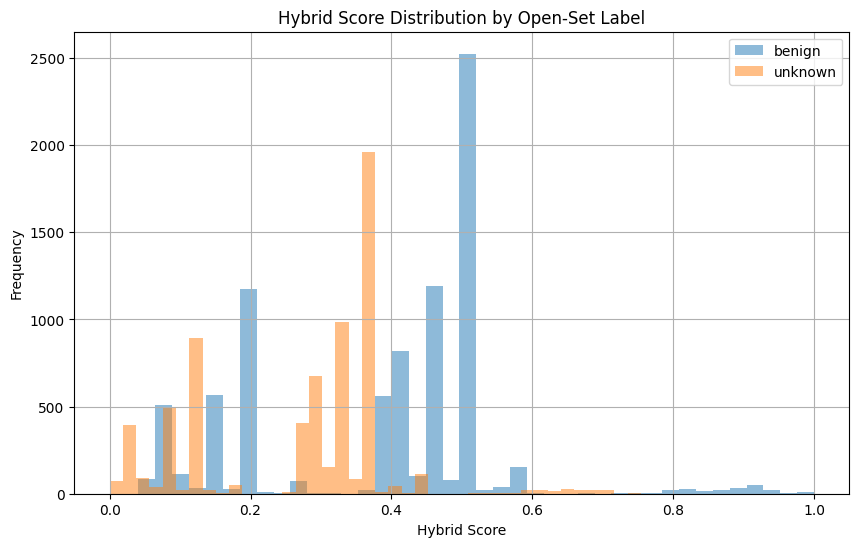

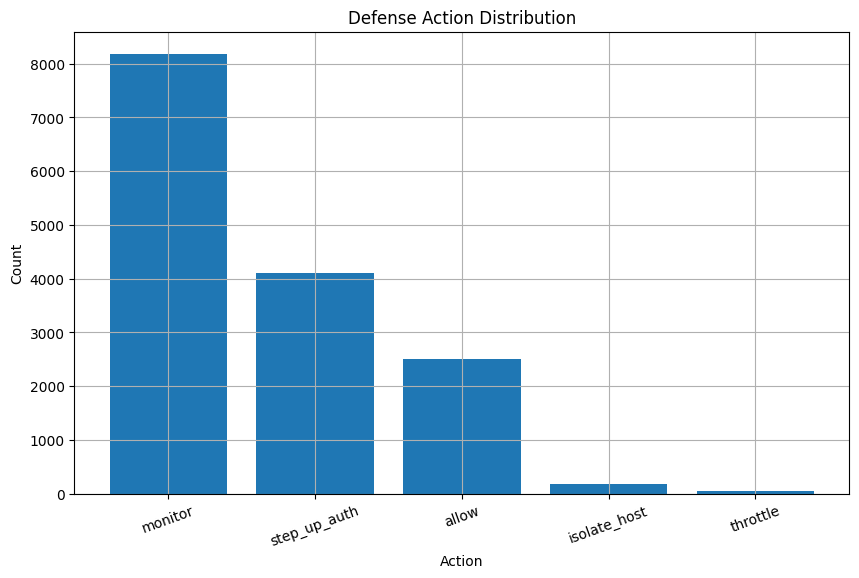

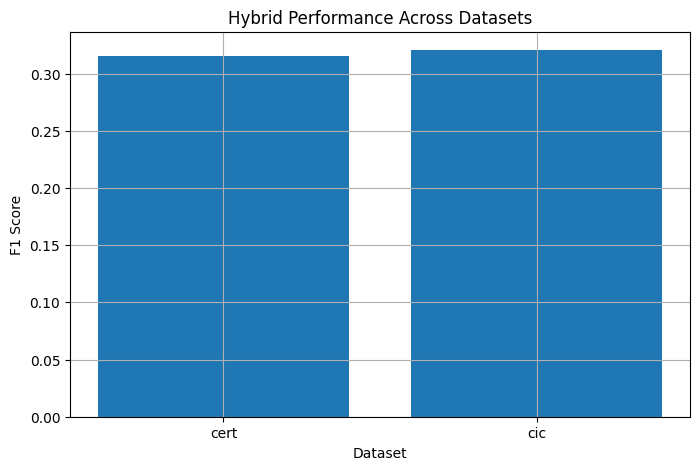

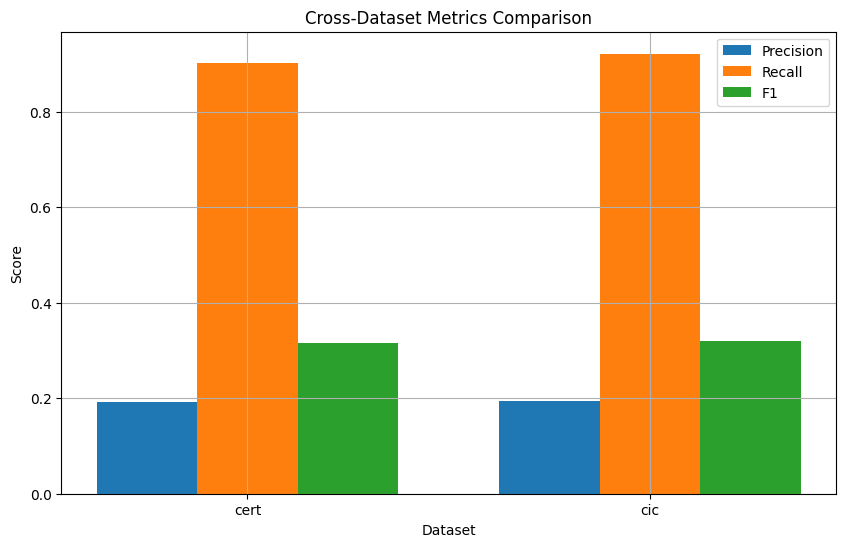

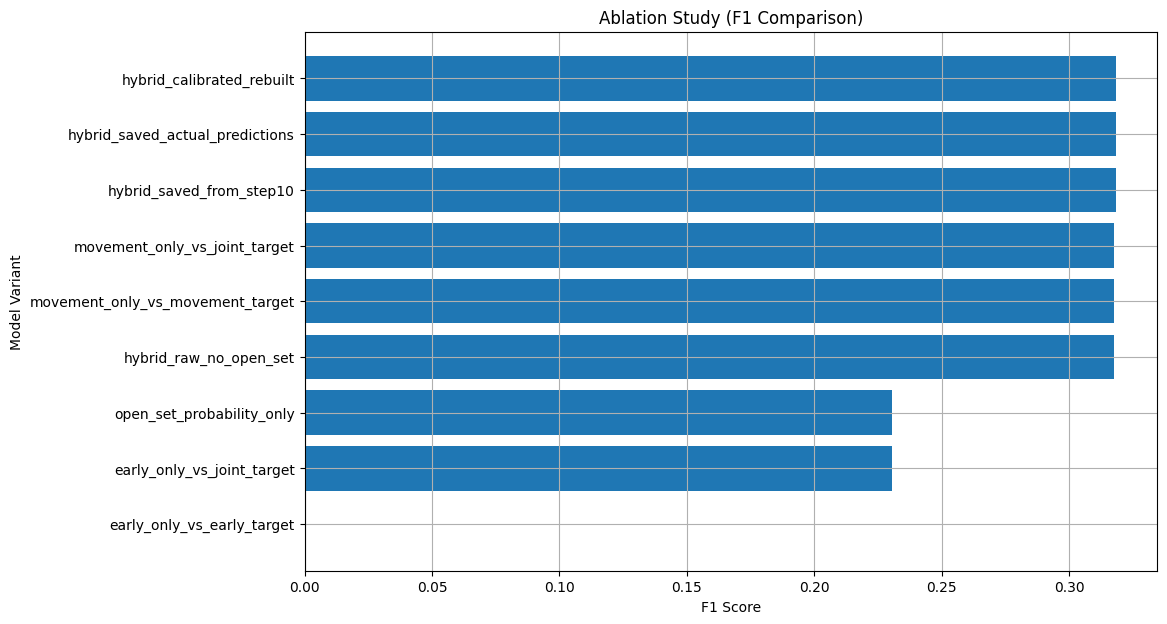

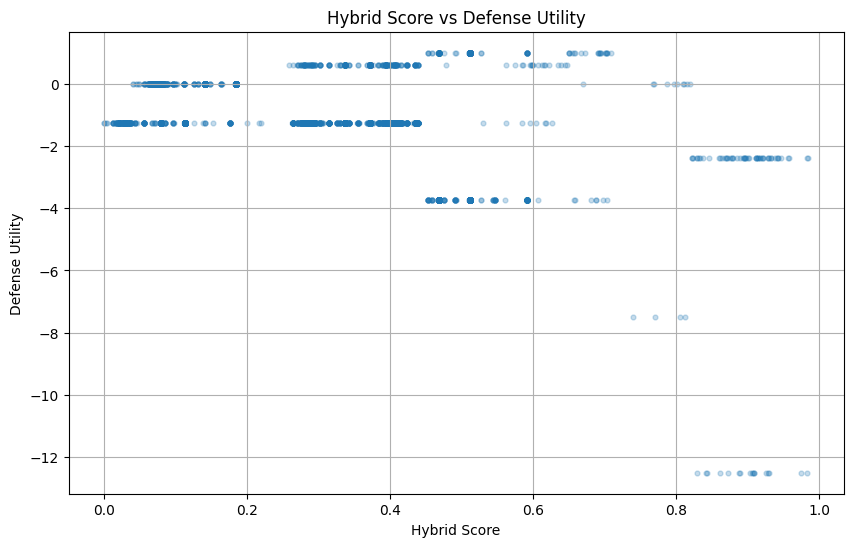

Saved figures:
- /kaggle/working/step16_outputs/fig1_score_distribution.png
- /kaggle/working/step16_outputs/fig2_defense_actions.png
- /kaggle/working/step16_outputs/fig3_cross_dataset_f1.png
- /kaggle/working/step16_outputs/fig4_metrics.png
- /kaggle/working/step16_outputs/fig5_ablation.png
- /kaggle/working/step16_outputs/fig6_score_vs_utility.png

 STEP 16 COMPLETE


In [18]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

# -------------------------
# Paths
# -------------------------
STEP10_DIR = "/kaggle/working/step10_outputs"
STEP11_DIR = "/kaggle/working/step11_outputs"
STEP13_DIR = "/kaggle/working/step13_outputs"
STEP14_DIR = "/kaggle/working/step14_outputs"
STEP85_DIR = "/kaggle/working/step85_outputs"
STEP16_DIR = "/kaggle/working/step16_outputs"
os.makedirs(STEP16_DIR, exist_ok=True)

HYBRID_PATH = os.path.join(STEP10_DIR, "hybrid_predictions.parquet")
DECISION_PATH = os.path.join(STEP11_DIR, "defense_decisions.parquet")
OPEN_PATH = os.path.join(STEP85_DIR, "open_set_results.parquet")
CROSS_PATH = os.path.join(STEP13_DIR, "cross_dataset_metrics.csv")
ABLATION_PATH = os.path.join(STEP14_DIR, "ablation_metrics.csv")

# -------------------------
# Load
# -------------------------
hybrid_df = pd.read_parquet(HYBRID_PATH)
decision_df = pd.read_parquet(DECISION_PATH)
open_df = pd.read_parquet(OPEN_PATH)

# Sync length of datasets to avoid mismatches
n = min(len(hybrid_df), len(decision_df), len(open_df))
hybrid_df = hybrid_df.iloc[:n].reset_index(drop=True)
decision_df = decision_df.iloc[:n].reset_index(drop=True)
open_df = open_df.iloc[:n].reset_index(drop=True)

# Adding extra columns for evaluation
hybrid_df["open_set_label"] = open_df["open_set_label"].astype(str)
hybrid_df["source"] = open_df["source"].astype(str)
decision_df["source"] = hybrid_df["source"]

# Read cross-dataset metrics and ablation study files
cross_df = pd.read_csv(CROSS_PATH) if os.path.exists(CROSS_PATH) else pd.DataFrame()
ablation_df = pd.read_csv(ABLATION_PATH) if os.path.exists(ABLATION_PATH) else pd.DataFrame()

saved = []

# Function to save and display the figure
def save_and_show(fig, path):
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    saved.append(path)

# -------------------------
# Figure 1: Hybrid score distribution
# -------------------------
fig = plt.figure(figsize=(10, 6))
for label in sorted(hybrid_df["open_set_label"].dropna().unique()):
    vals = hybrid_df.loc[hybrid_df["open_set_label"] == label, "hybrid_score"]
    plt.hist(vals, bins=40, alpha=0.5, label=label)

plt.title("Hybrid Score Distribution by Open-Set Label")
plt.xlabel("Hybrid Score")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)  # Added grid for better readability
save_and_show(fig, os.path.join(STEP16_DIR, "fig1_score_distribution.png"))

# -------------------------
# Figure 2: Defense actions
# -------------------------
fig = plt.figure(figsize=(10, 6))
counts = decision_df["defense_action"].value_counts()
plt.bar(counts.index.astype(str), counts.values)
plt.title("Defense Action Distribution")
plt.xlabel("Action")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.grid(True)
save_and_show(fig, os.path.join(STEP16_DIR, "fig2_defense_actions.png"))

# -------------------------
# Figure 3: Cross-dataset F1
# -------------------------
fig = plt.figure(figsize=(8, 5))
if not cross_df.empty:
    plt.bar(cross_df["source"].astype(str), cross_df["f1"].astype(float))
    plt.title("Hybrid Performance Across Datasets")
    plt.xlabel("Dataset")
    plt.ylabel("F1 Score")
    plt.grid(True)
    save_and_show(fig, os.path.join(STEP16_DIR, "fig3_cross_dataset_f1.png"))

# -------------------------
# Figure 4: Precision / Recall / F1
# -------------------------
x = np.arange(len(cross_df))
w = 0.25

fig = plt.figure(figsize=(10, 6))
if not cross_df.empty:
    plt.bar(x - w, cross_df["precision"].astype(float), width=w, label="Precision")
    plt.bar(x,     cross_df["recall"].astype(float),    width=w, label="Recall")
    plt.bar(x + w, cross_df["f1"].astype(float),        width=w, label="F1")
    plt.xticks(x, cross_df["source"].astype(str))
    plt.title("Cross-Dataset Metrics Comparison")
    plt.xlabel("Dataset")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True)
    save_and_show(fig, os.path.join(STEP16_DIR, "fig4_metrics.png"))

# -------------------------
# Figure 5: Ablation study
# -------------------------
top = ablation_df.sort_values("f1", ascending=True) if not ablation_df.empty else pd.DataFrame()

fig = plt.figure(figsize=(11, 7))
if not ablation_df.empty:
    plt.barh(top["model"].astype(str), top["f1"].astype(float))
    plt.title("Ablation Study (F1 Comparison)")
    plt.xlabel("F1 Score")
    plt.ylabel("Model Variant")
    plt.grid(True)
    save_and_show(fig, os.path.join(STEP16_DIR, "fig5_ablation.png"))

# -------------------------
# Figure 6: Score vs utility
# -------------------------
sample = pd.DataFrame({
    "score": pd.to_numeric(hybrid_df["hybrid_score"], errors="coerce"),
    "utility": pd.to_numeric(decision_df["defense_utility"], errors="coerce")
}).dropna().sample(min(5000, len(hybrid_df)), random_state=42)

fig = plt.figure(figsize=(10, 6))
plt.scatter(sample["score"], sample["utility"], alpha=0.25, s=12)
plt.title("Hybrid Score vs Defense Utility")
plt.xlabel("Hybrid Score")
plt.ylabel("Defense Utility")
plt.grid(True)
save_and_show(fig, os.path.join(STEP16_DIR, "fig6_score_vs_utility.png"))

# -------------------------
# Save summary
# -------------------------
summary = {"figures": saved}
with open(os.path.join(STEP16_DIR, "step16_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("Saved figures:")
for s in saved:
    print("-", s)

print("\n STEP 16 COMPLETE")

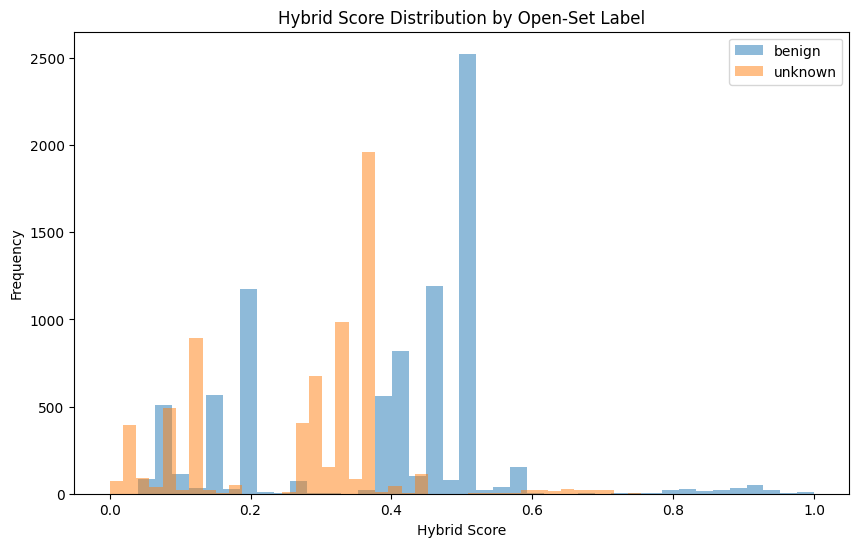

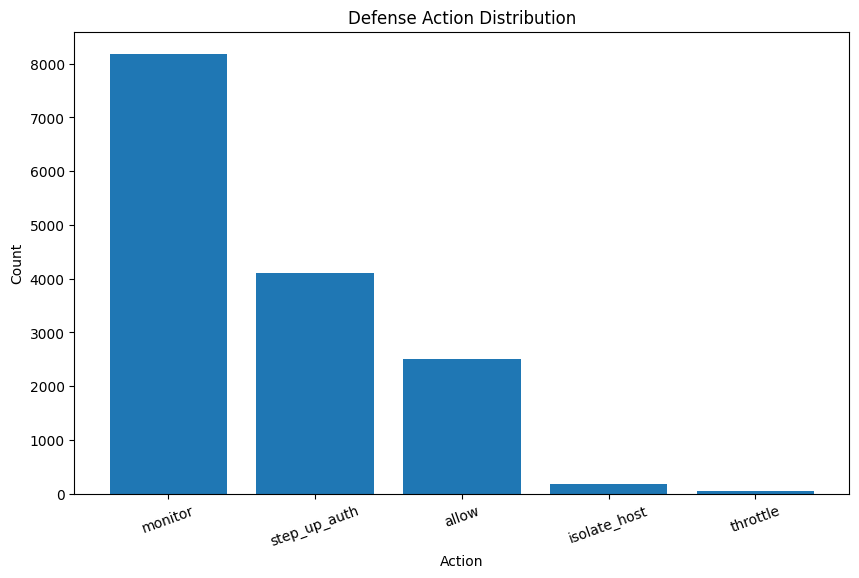

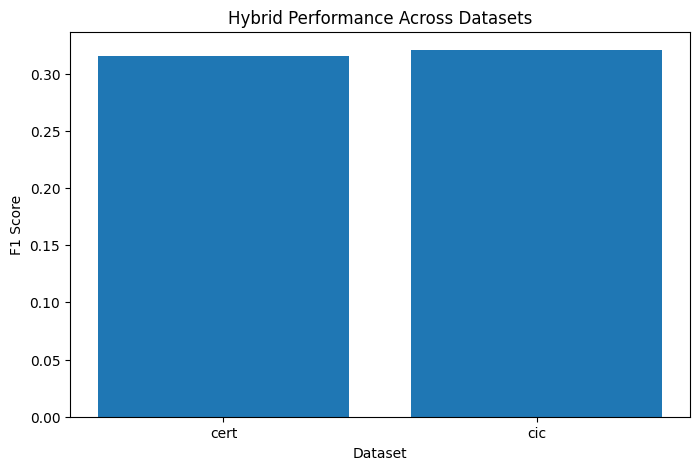

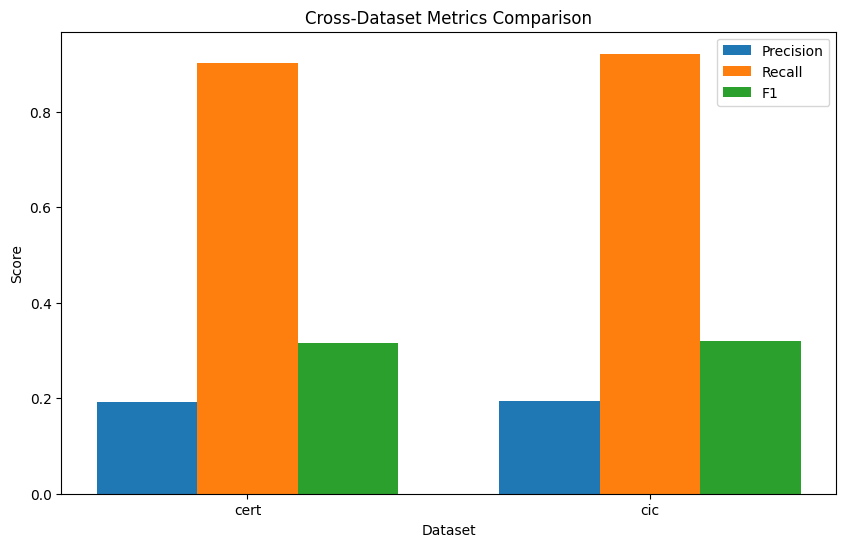

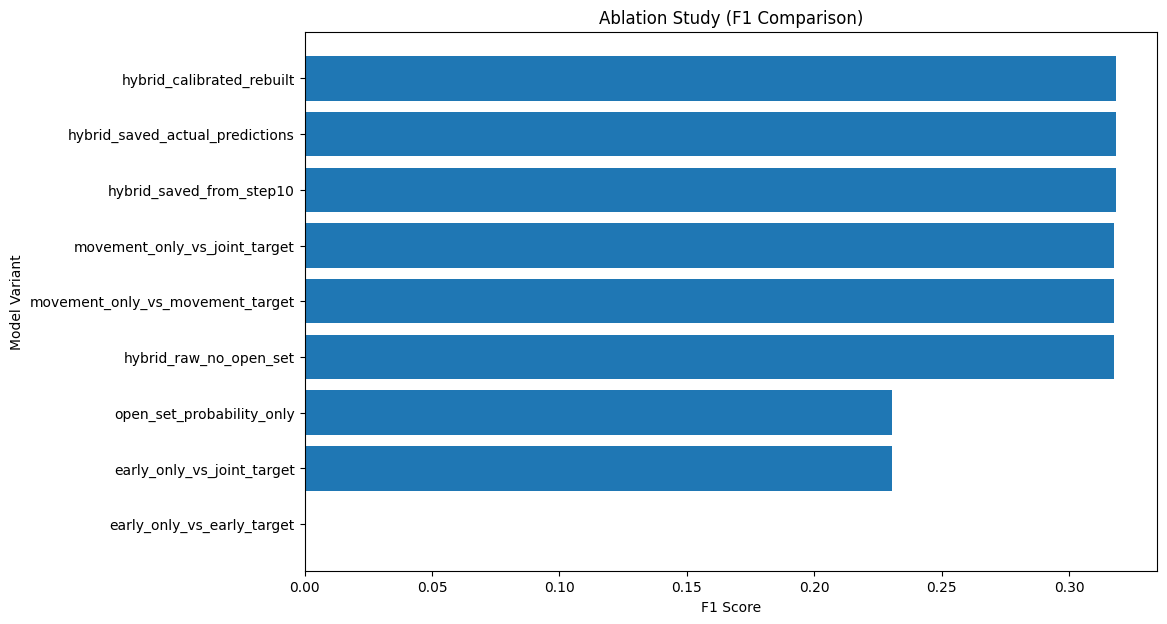

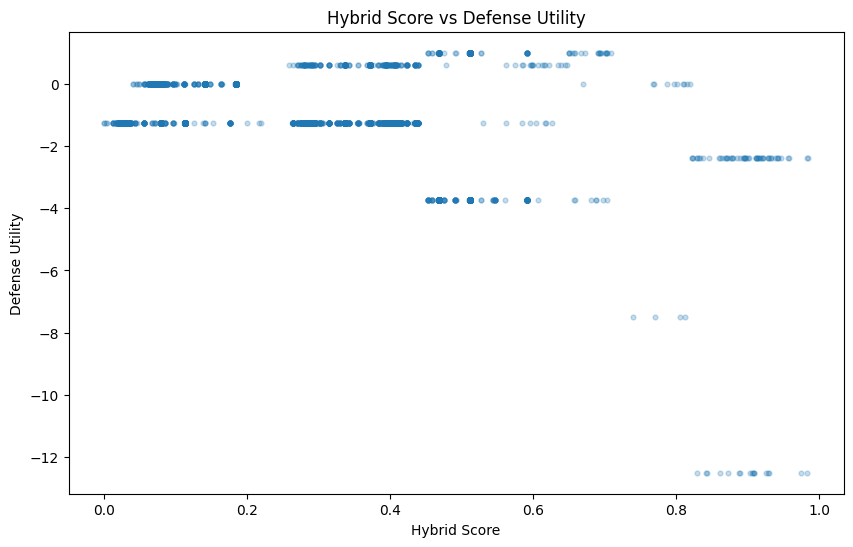

Saved figures:
- /kaggle/working/step16_outputs/fig1_score_distribution.png
- /kaggle/working/step16_outputs/fig2_defense_actions.png
- /kaggle/working/step16_outputs/fig3_cross_dataset_f1.png
- /kaggle/working/step16_outputs/fig4_metrics.png
- /kaggle/working/step16_outputs/fig5_ablation.png
- /kaggle/working/step16_outputs/fig6_score_vs_utility.png

✅ STEP 16 COMPLETE


In [19]:
# =========================
# STEP 16: VISUALIZATION
# Save + show figures inline
# =========================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

# -------------------------
# Paths
# -------------------------
STEP10_DIR = "/kaggle/working/step10_outputs"
STEP11_DIR = "/kaggle/working/step11_outputs"
STEP13_DIR = "/kaggle/working/step13_outputs"
STEP14_DIR = "/kaggle/working/step14_outputs"
STEP85_DIR = "/kaggle/working/step85_outputs"
STEP16_DIR = "/kaggle/working/step16_outputs"
os.makedirs(STEP16_DIR, exist_ok=True)

HYBRID_PATH = os.path.join(STEP10_DIR, "hybrid_predictions.parquet")
DECISION_PATH = os.path.join(STEP11_DIR, "defense_decisions.parquet")
OPEN_PATH = os.path.join(STEP85_DIR, "open_set_results.parquet")
CROSS_PATH = os.path.join(STEP13_DIR, "cross_dataset_metrics.csv")
ABLATION_PATH = os.path.join(STEP14_DIR, "ablation_metrics.csv")

# -------------------------
# Load
# -------------------------
hybrid_df = pd.read_parquet(HYBRID_PATH)
decision_df = pd.read_parquet(DECISION_PATH)
open_df = pd.read_parquet(OPEN_PATH)

n = min(len(hybrid_df), len(decision_df), len(open_df))
hybrid_df = hybrid_df.iloc[:n].reset_index(drop=True)
decision_df = decision_df.iloc[:n].reset_index(drop=True)
open_df = open_df.iloc[:n].reset_index(drop=True)

hybrid_df["open_set_label"] = open_df["open_set_label"].astype(str)
hybrid_df["source"] = open_df["source"].astype(str)
decision_df["source"] = hybrid_df["source"]

cross_df = pd.read_csv(CROSS_PATH)
ablation_df = pd.read_csv(ABLATION_PATH)

saved = []

def save_and_show(fig, path):
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    saved.append(path)

# -------------------------
# Figure 1: Hybrid score distribution
# -------------------------
fig = plt.figure(figsize=(10, 6))
for label in sorted(hybrid_df["open_set_label"].dropna().unique()):
    vals = hybrid_df.loc[hybrid_df["open_set_label"] == label, "hybrid_score"]
    plt.hist(vals, bins=40, alpha=0.5, label=label)

plt.title("Hybrid Score Distribution by Open-Set Label")
plt.xlabel("Hybrid Score")
plt.ylabel("Frequency")
plt.legend()
save_and_show(fig, os.path.join(STEP16_DIR, "fig1_score_distribution.png"))

# -------------------------
# Figure 2: Defense actions
# -------------------------
fig = plt.figure(figsize=(10, 6))
counts = decision_df["defense_action"].value_counts()
plt.bar(counts.index.astype(str), counts.values)
plt.title("Defense Action Distribution")
plt.xlabel("Action")
plt.ylabel("Count")
plt.xticks(rotation=20)
save_and_show(fig, os.path.join(STEP16_DIR, "fig2_defense_actions.png"))

# -------------------------
# Figure 3: Cross-dataset F1
# -------------------------
fig = plt.figure(figsize=(8, 5))
plt.bar(cross_df["source"].astype(str), cross_df["f1"].astype(float))
plt.title("Hybrid Performance Across Datasets")
plt.xlabel("Dataset")
plt.ylabel("F1 Score")
save_and_show(fig, os.path.join(STEP16_DIR, "fig3_cross_dataset_f1.png"))

# -------------------------
# Figure 4: Precision / Recall / F1
# -------------------------
x = np.arange(len(cross_df))
w = 0.25

fig = plt.figure(figsize=(10, 6))
plt.bar(x - w, cross_df["precision"].astype(float), width=w, label="Precision")
plt.bar(x,     cross_df["recall"].astype(float),    width=w, label="Recall")
plt.bar(x + w, cross_df["f1"].astype(float),        width=w, label="F1")
plt.xticks(x, cross_df["source"].astype(str))
plt.title("Cross-Dataset Metrics Comparison")
plt.xlabel("Dataset")
plt.ylabel("Score")
plt.legend()
save_and_show(fig, os.path.join(STEP16_DIR, "fig4_metrics.png"))

# -------------------------
# Figure 5: Ablation study
# -------------------------
top = ablation_df.sort_values("f1", ascending=True)

fig = plt.figure(figsize=(11, 7))
plt.barh(top["model"].astype(str), top["f1"].astype(float))
plt.title("Ablation Study (F1 Comparison)")
plt.xlabel("F1 Score")
plt.ylabel("Model Variant")
save_and_show(fig, os.path.join(STEP16_DIR, "fig5_ablation.png"))

# -------------------------
# Figure 6: Score vs utility
# -------------------------
sample = pd.DataFrame({
    "score": pd.to_numeric(hybrid_df["hybrid_score"], errors="coerce"),
    "utility": pd.to_numeric(decision_df["defense_utility"], errors="coerce")
}).dropna().sample(min(5000, len(hybrid_df)), random_state=42)

fig = plt.figure(figsize=(10, 6))
plt.scatter(sample["score"], sample["utility"], alpha=0.25, s=12)
plt.title("Hybrid Score vs Defense Utility")
plt.xlabel("Hybrid Score")
plt.ylabel("Defense Utility")
save_and_show(fig, os.path.join(STEP16_DIR, "fig6_score_vs_utility.png"))

# -------------------------
# Save summary
# -------------------------
summary = {"figures": saved}
with open(os.path.join(STEP16_DIR, "step16_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("Saved figures:")
for s in saved:
    print("-", s)

print("\n✅ STEP 16 COMPLETE")